<center><strong>Deep Learning</strong><br />
<strong><font color="blue">Departemen Informatika - Institut Teknologi Sepuluh Nopember</font></strong><br />
</center>

<strong>Outline Hands-On: Klasifikasi Emosi dengan Sequence Models</strong><br />
<li> Pengenalan Sequence Modeling & Klasifikasi Emosi </li>
<li> Recurrent Neural Network (RNN) & Vanishing Gradient </li>
<li> Long Short-Term Memory (LSTM) </li>
<li> Bidirectional LSTM (BiLSTM) </li>
<li> Dataset & Text Preprocessing (Indonesian Emotion Dataset) </li>
<li> Implementasi & Perbandingan SimpleRNN, LSTM, BiLSTM </li>
<li> Eksperimen Konfigurasi Model </li>
<li> Tugas Mini Project </li>

---

## Setup & Persiapan Environment

<p><strong><font color="red">PENTING:</font></strong> Pastikan runtime Google Colab menggunakan <strong>GPU</strong> untuk mempercepat proses training.</p>

<p>Cara mengaktifkan GPU di Google Colab:</p>
<ol>
    <li>Klik menu <strong>Runtime</strong> → <strong>Change runtime type</strong></li>
    <li>Pada <strong>Hardware accelerator</strong>, pilih <strong>GPU (T4)</strong></li>
    <li>Klik <strong>Save</strong></li>
</ol>

In [ ]:
# Install library yang dibutuhkan
!pip install datasets PySastrawi nltk wordcloud -q

# Import semua library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from tqdm import tqdm

import re
import string
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, GRU, Bidirectional,
    Dense, Dropout, Input, GlobalMaxPooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

from datasets import load_dataset

nltk.download('stopwords', quiet=True)

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 7.7 MB/s eta 0:00:00
TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 1. Pengenalan Sequence Modeling & Klasifikasi Emosi

<p><strong>Sequence Modeling</strong> adalah paradigma deep learning untuk memproses data yang memiliki <em>urutan</em> dan <em>konteks</em>. Berbeda dengan Feedforward Neural Network yang memperlakukan setiap input secara independen, sequence model mampu mengingat informasi dari elemen-elemen sebelumnya.</p>

<p>Beberapa contoh data sequential:</p>
<ul>
    <li><strong>Teks</strong> — kalimat, tweet, artikel (urutan kata penting untuk makna)</li>
    <li><strong>Audio</strong> — gelombang suara, sinyal medis (EEG, ECG)</li>
    <li><strong>Time Series</strong> — harga saham, cuaca, sensor IoT</li>
    <li><strong>Video</strong> — urutan frame yang membentuk gerakan</li>
</ul>

### Mengapa Feedforward NN Tidak Cukup untuk Teks?

<p>Perhatikan dua kalimat berikut:</p>
<ul>
    <li>"Saya <strong>tidak</strong> takut" → bisa bermakna berani, bukan fearful</li>
    <li>"Saya takut, <strong>tidak</strong> berani keluar" → jelas bermakna fearful</li>
</ul>

<p>Kata "tidak" memiliki makna yang berbeda tergantung konteks dan posisinya. Feedforward NN memiliki tiga kelemahan kritis untuk data teks:</p>

<table border="1" cellpadding="8" cellspacing="0">
<tr><th>Masalah</th><th>Penjelasan</th><th>Dampak</th></tr>
<tr><td><strong>Fixed-size input</strong></td><td>FNN membutuhkan input dengan panjang tetap</td><td>Tidak bisa menangani teks dengan panjang bervariasi</td></tr>
<tr><td><strong>Tidak ada memory</strong></td><td>Setiap kata diproses secara independen</td><td>Tidak bisa memahami konteks antar kata</td></tr>
<tr><td><strong>No parameter sharing</strong></td><td>Posisi kata yang berbeda memiliki bobot yang berbeda</td><td>Tidak efisien dan tidak generalisasi dengan baik</td></tr>
</table>

### Klasifikasi Emosi dari Teks

<p><strong>Emotion Classification</strong> adalah tugas NLP untuk mendeteksi <em>emosi yang diekspresikan</em> dalam sebuah teks. Berbeda dari analisis sentimen biner (positif/negatif), klasifikasi emosi bersifat <strong>multi-kelas</strong> dan lebih granular.</p>

<p>Pada hands-on ini kita menggunakan dataset <strong>talithaolga/Indonesian-Emotion-Classification</strong> — 73.672 tweet berbahasa Indonesia dengan 6 kelas emosi:</p>

<table border="1" cellpadding="8" cellspacing="0">
<tr><th>Emosi</th><th>Emoji</th><th>Deskripsi Singkat</th></tr>
<tr><td><strong>angry</strong></td><td>😡</td><td>Marah, kesal, tidak puas</td></tr>
<tr><td><strong>disgusted</strong></td><td>🤢</td><td>Jijik, muak, tidak suka</td></tr>
<tr><td><strong>fearful</strong></td><td>😨</td><td>Takut, cemas, khawatir</td></tr>
<tr><td><strong>happy</strong></td><td>😊</td><td>Senang, bahagia, antusias</td></tr>
<tr><td><strong>neutral</strong></td><td>😐</td><td>Netral, informatif, tidak emosional</td></tr>
<tr><td><strong>sad</strong></td><td>😢</td><td>Sedih, kecewa, berduka</td></tr>
</table>

---
## 2. Recurrent Neural Network (RNN)

<p><strong>RNN (Recurrent Neural Network)</strong> mengatasi keterbatasan FNN dengan menambahkan <strong>hidden state</strong> — semacam "memori jangka pendek" yang merangkum informasi dari semua timestep sebelumnya.</p>

### Cara Kerja RNN

<p>Pada setiap timestep <em>t</em>, RNN menerima dua input:</p>
<ol>
    <li><strong>x<sub>t</sub></strong> — input saat ini (misalnya: representasi vektor kata ke-t)</li>
    <li><strong>s<sub>t-1</sub></strong> — hidden state dari timestep sebelumnya ("memori")</li>
</ol>

<p>Dan menghasilkan hidden state baru:</p>

<p style="text-align:center; font-size:15px;"><code>s<sub>t</sub> = tanh(W · x<sub>t</sub> + U · s<sub>t-1</sub> + b)</code></p>

<p>Kunci penting: <strong>W</strong> dan <strong>U</strong> adalah bobot yang <em>sama</em> di semua timestep (parameter sharing!).</p>

### Unfolding RNN

```
  Kata:    "film"      "ini"      "bagus"      "sekali"
            x₀          x₁          x₂            x₃
             │           │           │              │
      s₀ → [RNN] → s₁ → [RNN] → s₂ → [RNN] → s₃ → [RNN] → s₄ → output
             ↑  W    ↑  W         ↑  W          ↑  W
             └──U────┘            └──U───────────┘
         (bobot W dan U SAMA di semua timestep)
```

### Masalah Vanishing Gradient pada RNN

<p>RNN dilatih menggunakan <strong>Backpropagation Through Time (BPTT)</strong>. Saat gradient dipropagasikan mundur melewati banyak timestep, gradient dihitung sebagai produk berantai:</p>

<p style="text-align:center;"><code>∂J/∂W = Σ<sub>t</sub> Σ<sub>k≤t</sub> (∂J<sub>t</sub>/∂y<sub>t</sub>) · (∂s<sub>t</sub>/∂s<sub>k</sub>) · (∂s<sub>k</sub>/∂W)</code></p>

<p>Karena bobot W diinisialisasi dari distribusi normal (kebanyakan < 1) dan turunan fungsi aktivasi tanh/sigmoid selalu < 1, perkalian banyak bilangan kecil ini menyebabkan <strong>vanishing gradient</strong>: gradient mendekati nol untuk timestep yang jauh, sehingga model gagal belajar dependensi jarak jauh.</p>

<table border="1" cellpadding="8" cellspacing="0">
<tr><th>Masalah</th><th>Penyebab</th><th>Akibat</th></tr>
<tr><td><strong>Vanishing Gradient</strong></td><td>Produk banyak nilai < 1 → mendekati 0</td><td>Model tidak bisa belajar long-term dependency</td></tr>
<tr><td><strong>Exploding Gradient</strong></td><td>Produk banyak nilai > 1 → sangat besar</td><td>Bobot tidak stabil (NaN)</td></tr>
</table>

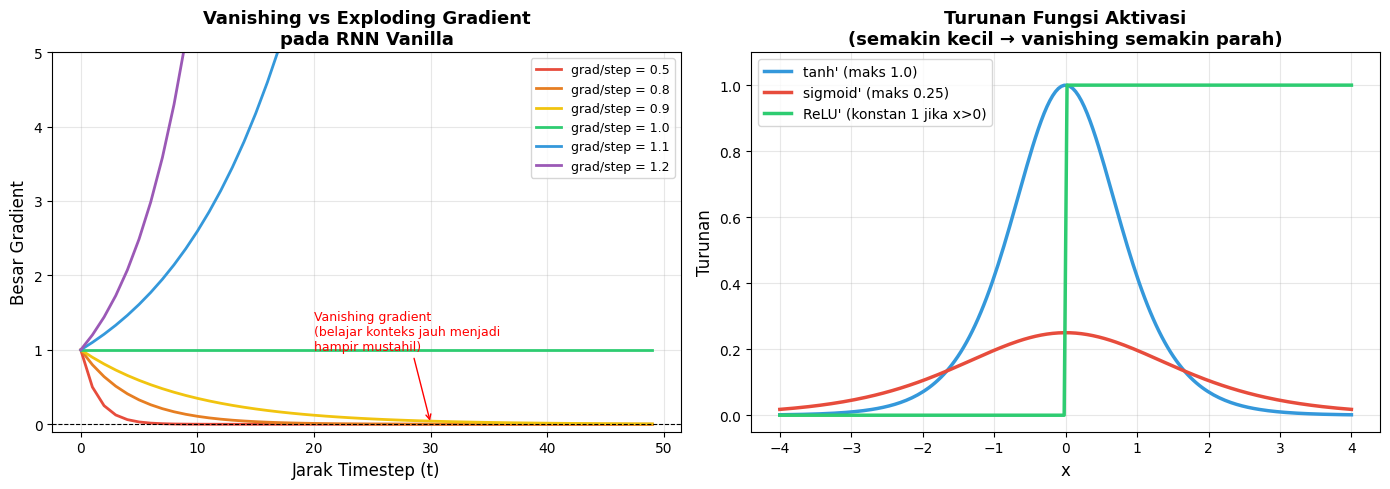

Kesimpulan:
  Gradient dengan nilai 0.5 setelah 20 timestep: 9.54e-07
  Gradient dengan nilai 0.9 setelah 20 timestep: 0.1216
  Gradient dengan nilai 1.1 setelah 20 timestep: 6.73 (exploding!)


In [ ]:
# Demonstrasi: Simulasi vanishing gradient pada RNN vanilla
import numpy as np
import matplotlib.pyplot as plt

# Simulasikan perkalian gradient melewati T timestep
# Jika setiap ∂s_t/∂s_{t-1} memiliki nilai rata-rata 'grad_val'
T = 50  # jumlah timestep
grad_values = [0.5, 0.8, 0.9, 1.0, 1.1, 1.2]  # berbagai nilai gradient per step
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for val, color in zip(grad_values, colors):
    gradients = [val**t for t in range(T)]
    label = f'grad/step = {val}'
    ax1.plot(range(T), gradients, color=color, label=label, linewidth=2)

ax1.set_xlabel('Jarak Timestep (t)', fontsize=12)
ax1.set_ylabel('Besar Gradient', fontsize=12)
ax1.set_title('Vanishing vs Exploding Gradient\npada RNN Vanilla', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_ylim(-0.1, 5)
ax1.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax1.grid(True, alpha=0.3)
ax1.annotate('Vanishing gradient\n(belajar konteks jauh menjadi\nhampir mustahil)',
             xy=(30, 0.01), xytext=(20, 1.0),
             arrowprops=dict(arrowstyle='->', color='red'),
             color='red', fontsize=9)

# Perbandingan: tanh vs ReLU derivative
x = np.linspace(-4, 4, 200)
tanh_deriv = 1 - np.tanh(x)**2
sigmoid = 1 / (1 + np.exp(-x))
sigmoid_deriv = sigmoid * (1 - sigmoid)
relu_deriv = np.where(x > 0, 1.0, 0.0)

ax2.plot(x, tanh_deriv,    color='#3498db', label="tanh' (maks 1.0)", linewidth=2.5)
ax2.plot(x, sigmoid_deriv, color='#e74c3c', label="sigmoid' (maks 0.25)", linewidth=2.5)
ax2.plot(x, relu_deriv,    color='#2ecc71', label="ReLU' (konstan 1 jika x>0)", linewidth=2.5)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('Turunan', fontsize=12)
ax2.set_title('Turunan Fungsi Aktivasi\n(semakin kecil → vanishing semakin parah)',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

print("Kesimpulan:")
print(f"  Gradient dengan nilai 0.5 setelah 20 timestep: {0.5**20:.2e}")
print(f"  Gradient dengan nilai 0.9 setelah 20 timestep: {0.9**20:.4f}")
print(f"  Gradient dengan nilai 1.1 setelah 20 timestep: {1.1**20:.2f} (exploding!)")

<h3><font color="blue">Latihan 1:</font></h3>

<ul>
    <li>Pada grafik kiri, jika <code>grad/step = 0.9</code>, berapa besar gradient yang sampai ke timestep ke-50? Hitung secara manual lalu verifikasi dari grafik.</li>
    <li>Mengapa ReLU lebih tahan terhadap vanishing gradient dibandingkan tanh dan sigmoid? Jelaskan berdasarkan grafik turunan di sebelah kanan.</li>
    <li>Jika sebuah kalimat terdiri dari 100 kata, apa yang akan terjadi dengan kemampuan RNN vanilla untuk memahami kata di posisi awal saat memprediksi output akhir?</li>
</ul>

### Latihan 1

#### 1. Besar Gradient pada Timestep ke-50 (`grad/step = 0.9`)
* **Hitungan Manual:** Gradient awal pada $t = 0$ adalah $1$. Formula untuk menghitung gradient pada timestep ke-$t$ dengan faktor pengali konstan adalah:
    $$\text{Gradient}_t = \text{Gradient}_0 \times (\text{grad/step})^t$$
    Maka pada timestep ke-50 ($t = 50$):
    $$\text{Gradient}_{50} = 1 \times (0.9)^{50} \approx 0.00515$$

* **Verifikasi Grafik:** Pada grafik sebelah kiri, garis kuning yang merepresentasikan `grad/step = 0.9` terus menurun secara eksponensial. Pada sumbu X (Jarak Timestep) bernilai 50, posisi garis kuning tersebut berada sangat dekat di atas garis putus-putus hitam (nilai 0). Hal ini memverifikasi bahwa hasil hitungan manual ($\approx 0.00515$) sangat sesuai dengan visualisasi grafik.

---

#### 2. Alasan ReLU Lebih Tahan Terhadap *Vanishing Gradient*
Berdasarkan grafik turunan di sebelah kanan (*Turunan Fungsi Aktivasi*):
* **Fungsi Sigmoid & Tanh:** Nilai turunan dari fungsi `sigmoid` maksimum hanya **0.25**, sedangkan turunan `tanh` maksimum adalah **1.0** namun nilainya cepat mengecil mendekati 0 seiring menjauhnya nilai $x$ dari 0. Saat melakukan *backpropagation* pada RNN, turunan fungsi ini akan dikalikan berulang kali di setiap *timestep*. Perkalian berulang dari angka yang kurang dari 1 ($< 1$) menyebabkan nilai gradient menyusut secara eksponensial hingga mendekati nol (*vanishing gradient*).
* **Fungsi ReLU:** Turunan dari `ReLU` bernilai **konstan 1.0** untuk semua input positif ($x > 0$). Karena perkalian berulang dengan angka 1 tidak akan mengubah atau mengecilkan nilainya ($1 \times 1 \times 1 \dots = 1$), aliran gradient akan tetap stabil dan tidak mengalami penyusutan meskipun melewati banyak *timestep*.

---

#### 3. Dampak Kalimat 100 Kata pada Kemampuan RNN Vanilla
Jika sebuah kalimat terdiri dari 100 kata, RNN vanilla akan **gagal memahami atau mengingat konteks kata-kata yang berada di posisi awal** (kata-kata pertama) saat memprediksi output di akhir kalimat.

* **Penjelasan:** Jarak 100 *timestep* terlalu jauh untuk arsitektur RNN vanilla. Akibat dari perkalian berulang matriks bobot dan turunan fungsi aktivasi selama proses *backpropagation*, gradient yang mengalir mundur dari kata ke-100 menuju kata-kata awal akan mengalami *vanishing gradient* yang sangat parah (seperti yang ditunjukkan oleh tren garis merah/oranye pada grafik kiri). Tanpa aliran gradient yang sampai ke posisi awal, model tidak mampu memperbarui bobotnya untuk mempelajari hubungan jangka panjang (*Long-Term Dependencies*).

---
## 3. Long Short-Term Memory (LSTM)

<p><strong>LSTM</strong> diperkenalkan oleh Hochreiter & Schmidhuber (1997) sebagai solusi terhadap vanishing gradient pada RNN vanilla. LSTM memperkenalkan dua konsep baru:</p>
<ul>
    <li><strong>Cell State (c<sub>t</sub>)</strong> — "conveyor belt" yang membawa informasi jangka panjang dengan perubahan minimal</li>
    <li><strong>Gate Mechanism</strong> — tiga gerbang yang mengontrol aliran informasi secara selektif</li>
</ul>

### Tiga Gate LSTM

<table border="1" cellpadding="8" cellspacing="0">
<tr><th>Gate</th><th>Fungsi</th><th>Rumus</th></tr>
<tr>
    <td><strong>Forget Gate (f)</strong></td>
    <td>Memutuskan informasi apa dari cell state lama yang harus dilupakan (dihapus)</td>
    <td><code>f<sub>t</sub> = σ(W<sub>f</sub>·[s<sub>t-1</sub>, x<sub>t</sub>] + b<sub>f</sub>)</code></td>
</tr>
<tr>
    <td><strong>Input Gate (i)</strong></td>
    <td>Memutuskan informasi baru apa yang perlu disimpan ke dalam cell state</td>
    <td><code>i<sub>t</sub> = σ(W<sub>i</sub>·[s<sub>t-1</sub>, x<sub>t</sub>] + b<sub>i</sub>)</code></td>
</tr>
<tr>
    <td><strong>Output Gate (o)</strong></td>
    <td>Memutuskan bagian mana dari cell state yang akan dijadikan hidden state output</td>
    <td><code>o<sub>t</sub> = σ(W<sub>o</sub>·[s<sub>t-1</sub>, x<sub>t</sub>] + b<sub>o</sub>)</code></td>
</tr>
</table>

### Update Cell State dan Hidden State

<p>Kandidat cell state baru (informasi yang mungkin akan ditambahkan):</p>
<p style="text-align:center;"><code>c̃<sub>t</sub> = tanh(W<sub>c</sub>·[s<sub>t-1</sub>, x<sub>t</sub>] + b<sub>c</sub>)</code></p>

<p>Update cell state (kombinasi lupakan + tambahkan informasi baru):</p>
<p style="text-align:center;"><code>c<sub>t</sub> = f<sub>t</sub> ⊙ c<sub>t-1</sub> + i<sub>t</sub> ⊙ c̃<sub>t</sub></code></p>

<p>Output hidden state:</p>
<p style="text-align:center;"><code>s<sub>t</sub> = o<sub>t</sub> ⊙ tanh(c<sub>t</sub>)</code></p>

### Mengapa LSTM Mengatasi Vanishing Gradient?

<p>Perhatikan rumus update cell state: <code>c<sub>t</sub> = f<sub>t</sub> ⊙ c<sub>t-1</sub> + i<sub>t</sub> ⊙ c̃<sub>t</sub></code></p>
<p>Operasinya adalah <strong>penjumlahan</strong>, bukan perkalian berantai! Ini membuat gradient dapat mengalir tanpa mengecil secara eksponensial, sehingga LSTM bisa belajar dependensi jarak jauh.</p>

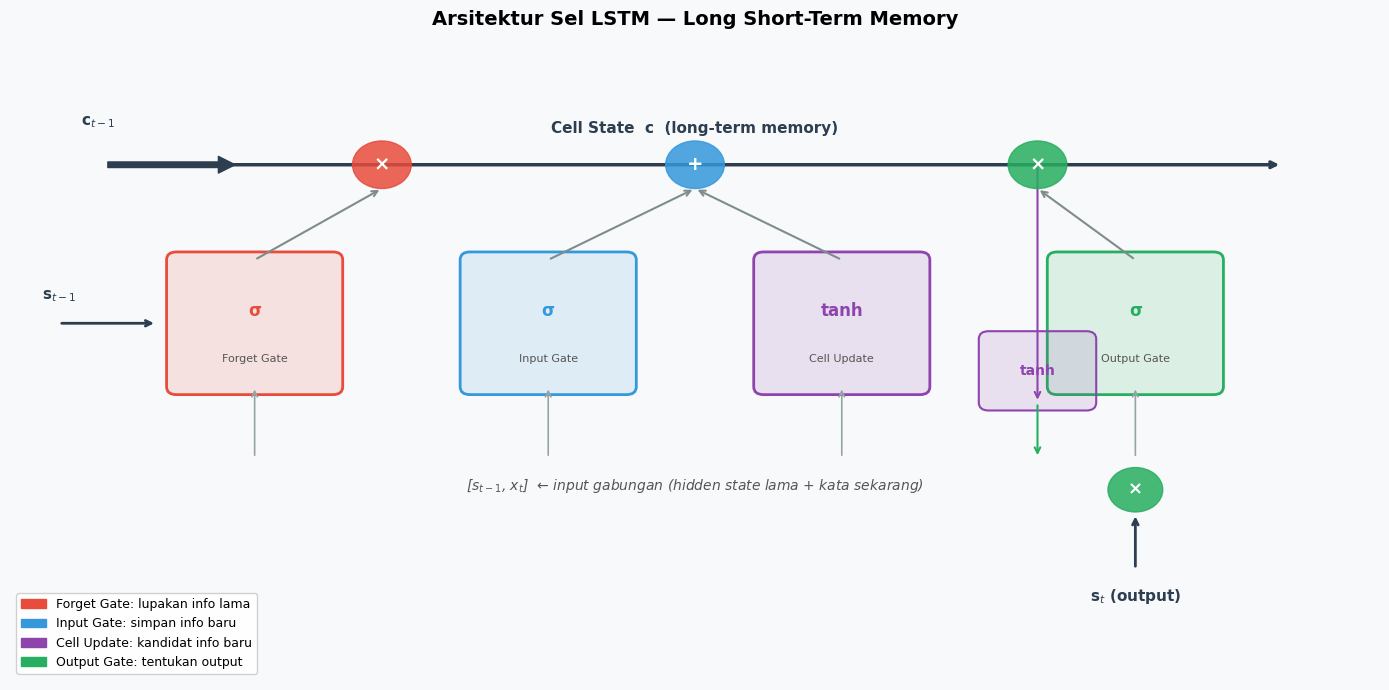

In [ ]:
# Visualisasi arsitektur LSTM cell secara diagram
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig, ax = plt.subplots(1, 1, figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

# --- Cell state line (conveyor belt) ---
ax.annotate('', xy=(13, 6.5), xytext=(1, 6.5),
            arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2.5))
ax.text(7, 6.9, 'Cell State  c  (long-term memory)', ha='center', fontsize=11,
        fontweight='bold', color='#2c3e50')

# --- Gate boxes ---
gate_configs = [
    (2.5, 4.5, 'Forget\nGate\nf', '#e74c3c', 'σ'),
    (5.5, 4.5, 'Input\nGate\ni', '#3498db', 'σ'),
    (8.5, 4.5, 'Cell\nUpdate\nc̃', '#8e44ad', 'tanh'),
    (11.5, 4.5, 'Output\nGate\no', '#27ae60', 'σ'),
]
for x, y, label, color, func in gate_configs:
    rect = FancyBboxPatch((x-0.8, y-0.8), 1.6, 1.6,
                           boxstyle='round,pad=0.1', linewidth=2,
                           edgecolor=color, facecolor=color + '22')
    ax.add_patch(rect)
    ax.text(x, y + 0.15, func, ha='center', va='center',
            fontsize=12, fontweight='bold', color=color)
    ax.text(x, y - 0.45, label.split('\n')[0] + ' ' + label.split('\n')[1],
            ha='center', va='center', fontsize=8, color='#555')

# --- Multiply/Add operations on cell state line ---
ops = [(3.8, 6.5, '×', '#e74c3c'), (7.0, 6.5, '+', '#3498db'), (10.5, 6.5, '×', '#27ae60')]
for x, y, sym, color in ops:
    circle = plt.Circle((x, y), 0.3, color=color, fill=True, alpha=0.85, zorder=5)
    ax.add_patch(circle)
    ax.text(x, y, sym, ha='center', va='center', fontsize=14, fontweight='bold',
            color='white', zorder=6)

# --- Arrows from gates to operations ---
arrows = [
    (2.5, 5.3, 3.8, 6.2), (5.5, 5.3, 7.0, 6.2),
    (8.5, 5.3, 7.0, 6.2), (11.5, 5.3, 10.5, 6.2),
]
for x1, y1, x2, y2 in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.5))

# --- Input x_t and s_{t-1} ---
for x_pos in [2.5, 5.5, 8.5, 11.5]:
    ax.annotate('', xy=(x_pos, 3.7), xytext=(x_pos, 2.8),
                arrowprops=dict(arrowstyle='->', color='#95a5a6', lw=1.2))
ax.text(7, 2.4, '[s$_{t-1}$, x$_t$]  ← input gabungan (hidden state lama + kata sekarang)',
        ha='center', fontsize=10, color='#555', style='italic')

# --- s_{t-1} input ---
ax.annotate('', xy=(1.5, 4.5), xytext=(0.5, 4.5),
            arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2))
ax.text(0.5, 4.8, 's$_{t-1}$', ha='center', fontsize=11, color='#2c3e50', fontweight='bold')

# --- c_{t-1} input ---
ax.annotate('', xy=(2.3, 6.5), xytext=(1, 6.5), arrowprops=dict(color='#2c3e50'))
ax.text(0.9, 7.0, 'c$_{t-1}$', ha='center', fontsize=11, color='#2c3e50', fontweight='bold')

# --- Tanh before output ---
tanh_box = FancyBboxPatch((10.0, 3.5), 1.0, 0.8, boxstyle='round,pad=0.1',
                           linewidth=1.5, edgecolor='#8e44ad', facecolor='#8e44ad22')
ax.add_patch(tanh_box)
ax.text(10.5, 3.9, 'tanh', ha='center', va='center', fontsize=10,
        color='#8e44ad', fontweight='bold')
ax.annotate('', xy=(10.5, 3.5), xytext=(10.5, 6.5),
            arrowprops=dict(arrowstyle='->', color='#8e44ad', lw=1.5))
ax.annotate('', xy=(10.5, 2.8), xytext=(10.5, 3.5),
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.5))

# --- Output s_t ---
mul_output = plt.Circle((11.5, 2.4), 0.28, color='#27ae60', fill=True, alpha=0.85, zorder=5)
ax.add_patch(mul_output)
ax.text(11.5, 2.4, '×', ha='center', va='center', fontsize=13, color='white',
        fontweight='bold', zorder=6)
ax.annotate('', xy=(11.5, 2.1), xytext=(11.5, 1.4),
            arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2))
ax.text(11.5, 1.0, 's$_t$ (output)', ha='center', fontsize=11, color='#2c3e50', fontweight='bold')

# --- Title ---
ax.set_title('Arsitektur Sel LSTM — Long Short-Term Memory',
             fontsize=14, fontweight='bold', pad=15)

# Legend
legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Forget Gate: lupakan info lama'),
    mpatches.Patch(color='#3498db', label='Input Gate: simpan info baru'),
    mpatches.Patch(color='#8e44ad', label='Cell Update: kandidat info baru'),
    mpatches.Patch(color='#27ae60', label='Output Gate: tentukan output'),
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

---
## 4. Bidirectional LSTM (BiLSTM)

<p><strong>BiLSTM</strong> memproses sequence dalam <strong>dua arah</strong> secara bersamaan:</p>
<ul>
    <li><strong>Forward LSTM</strong> — membaca teks dari kiri ke kanan (seperti membaca normal)</li>
    <li><strong>Backward LSTM</strong> — membaca teks dari kanan ke kiri (konteks dari depan)</li>
</ul>

<p>Output dari kedua arah digabungkan (concatenate/sum/average) sehingga setiap kata mendapatkan konteks dari <em>kedua sisi</em>.</p>

```
Kalimat:  "Makanan   di   restoran   ini   sangat   enak"
           w₁        w₂   w₃         w₄    w₅       w₆

Forward:  h₁→ ─── h₂→ ─── h₃→ ─── h₄→ ─── h₅→ ─── h₆→
          (melihat konteks: semua kata sebelumnya)

Backward: ←h₁ ─── ←h₂ ─── ←h₃ ─── ←h₄ ─── ←h₅ ─── ←h₆
          (melihat konteks: semua kata sesudahnya)

Output:   [h₁→, ←h₁] [h₂→, ←h₂] ... [h₆→, ←h₆]
          (setiap kata punya konteks LENGKAP dari kiri dan kanan)
```

### Perbandingan: LSTM vs BiLSTM

<table border="1" cellpadding="8" cellspacing="0">
<tr><th>Aspek</th><th>LSTM</th><th>BiLSTM</th></tr>
<tr><td><strong>Arah pemrosesan</strong></td><td>Kiri → Kanan saja</td><td>Kiri → Kanan DAN Kanan → Kiri</td></tr>
<tr><td><strong>Konteks kata</strong></td><td>Hanya konteks sebelumnya</td><td>Konteks sebelum DAN sesudah</td></tr>
<tr><td><strong>Jumlah parameter</strong></td><td>N parameter</td><td>~2N parameter</td></tr>
<tr><td><strong>Kecepatan training</strong></td><td>Lebih cepat</td><td>~2x lebih lambat</td></tr>
<tr><td><strong>Cocok untuk</strong></td><td>Time series, generasi teks, real-time</td><td>Klasifikasi teks, NER, analisis sentimen</td></tr>
<tr><td><strong>Contoh use case</strong></td><td>Prediksi kata berikutnya, chatbot</td><td>Analisis sentimen, Named Entity Recognition</td></tr>
</table>

<p><strong>Kapan BiLSTM lebih baik?</strong> Untuk task klasifikasi teks seperti analisis sentimen, di mana kita perlu memahami <em>seluruh kalimat</em> sebelum membuat keputusan, BiLSTM sangat unggul karena setiap kata mendapat konteks penuh dari dua arah.</p>

---
## 5. Dataset & Text Preprocessing

<p>Kita menggunakan dataset <strong><a href="https://huggingface.co/datasets/talithaolga/Indonesian-Emotion-Classification">talithaolga/Indonesian-Emotion-Classification</a></strong> dari Hugging Face — berisi <strong>73.672 tweet berbahasa Indonesia</strong> yang berlabel 6 kelas emosi dengan distribusi yang relatif seimbang (~15–18% per kelas).</p>

<table border="1" cellpadding="8" cellspacing="0">
<tr><th>Atribut</th><th>Detail</th></tr>
<tr><td><strong>Sumber</strong></td><td>Hugging Face Datasets — talithaolga/Indonesian-Emotion-Classification</td></tr>
<tr><td><strong>Jumlah data</strong></td><td>73.672 tweet berbahasa Indonesia</td></tr>
<tr><td><strong>Kelas</strong></td><td>angry, disgusted, fearful, happy, neutral, sad (6 kelas)</td></tr>
<tr><td><strong>Distribusi</strong></td><td>Relatif seimbang — tidak perlu oversampling</td></tr>
<tr><td><strong>Kolom</strong></td><td><code>text</code> (isi tweet), <code>label</code> (kelas emosi)</td></tr>
</table>

### Pipeline Preprocessing Teks

<p>Tweet berbahasa Indonesia mengandung banyak noise spesifik yang perlu dibersihkan. Pipeline yang kita terapkan (mengikuti praktik terbaik untuk data Twitter Bahasa Indonesia):</p>

<ol>
    <li><strong>Lowercase</strong> — Normalisasi huruf kapital</li>
    <li><strong>Hapus URL</strong> — <code>http://...</code> tidak berkontribusi pada emosi</li>
    <li><strong>Hapus mention & hashtag</strong> — <code>@user</code> dan <code>#tag</code></li>
    <li><strong>Hapus HTML entity</strong> — <code>&amp;</code>, <code>&lt;</code>, dll.</li>
    <li><strong>Hapus angka & tanda baca</strong> — Kurangi noise non-linguistik</li>
    <li><strong>Normalisasi karakter berulang</strong> — <em>hahaha</em> → <em>haha</em>, <em>kesel!!!</em> → <em>kesel!!</em></li>
    <li><strong>Hapus stopwords Bahasa Indonesia</strong> — NLTK + daftar kata gaul (gue, gw, aja, sih, dll.)</li>
    <li><strong>Stemming (PySastrawi)</strong> — Bentuk dasar kata Bahasa Indonesia</li>
</ol>

<p><strong>Catatan:</strong> Stemming dengan PySastrawi pada 73.000+ data membutuhkan waktu <strong>5–10 menit</strong>. Ini normal — PySastrawi adalah stemmer berbasis kamus yang akurat untuk Bahasa Indonesia.</p>

In [ ]:
# LOAD DATASET
from datasets import load_dataset

print("Mengunduh dataset dari Hugging Face...")
dataset = load_dataset("talithaolga/Indonesian-Emotion-Classification")
print("\nStruktur dataset:")
print(dataset)

# Konversi ke pandas DataFrame
df = dataset['train'].to_pandas()

print(f"\n=== Info Dataset ===")
print(f"Jumlah data  : {len(df):,}")
print(f"Kolom        : {df.columns.tolist()}")
print(f"\nCek missing value:")
print(df.isnull().sum())

print(f"\n=== Label / Kelas Emosi ===")
print(f"Nama kelas   : {sorted(df['label'].unique())}")
print(f"Jumlah kelas : {df['label'].nunique()}")

print(f"\n=== Distribusi Tiap Kelas ===")
print(df['label'].value_counts())

df.head()

Mengunduh dataset dari Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/137 [00:00<?, ?B/s]

emotion-dataset.csv:   0%|          | 0.00/9.56M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/73672 [00:00<?, ? examples/s]


Struktur dataset:
DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 73672
    })
})

=== Info Dataset ===
Jumlah data  : 73,672
Kolom        : ['label', 'text']

Cek missing value:
label    0
text     0
dtype: int64

=== Label / Kelas Emosi ===
Nama kelas   : ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad']
Jumlah kelas : 6

=== Distribusi Tiap Kelas ===
label
sad          13223
neutral      12652
happy        12439
disgusted    11958
fearful      11942
angry        11458
Name: count, dtype: int64


,label,text
0,disgusted,diem pake efek aged aja udah bikin mual. untun...
1,disgusted,jijik bgt boti. plislah kalo post muka2 yg bik...
2,disgusted,@sir_azri @kuasasiswa @sir_azri bekas polis ra...
3,disgusted,tim kapal prabted prabgib prabjok? tp kayanya ...
4,disgusted,@bluvingsm udh otomatis jijik mual muntah cokl...


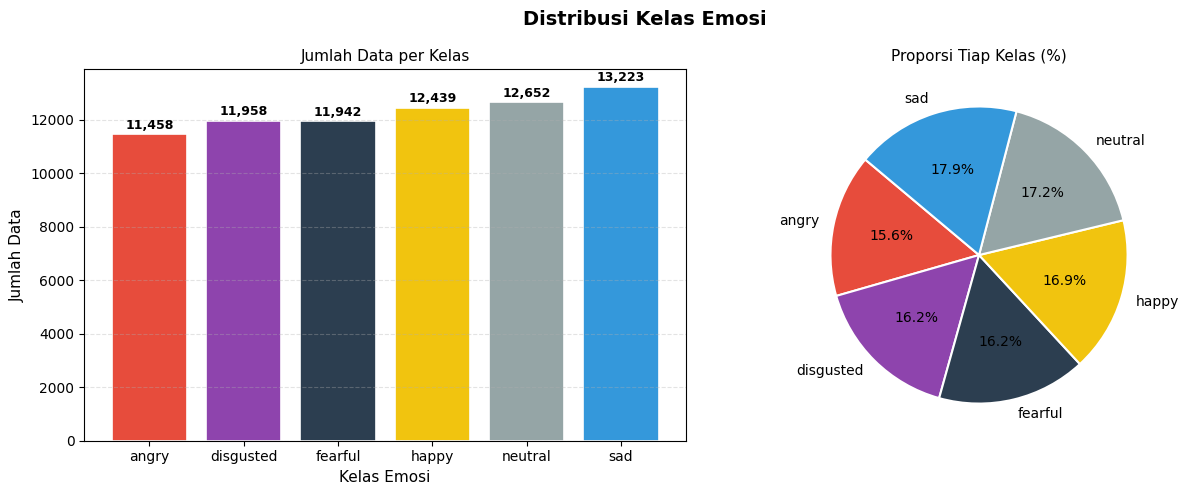

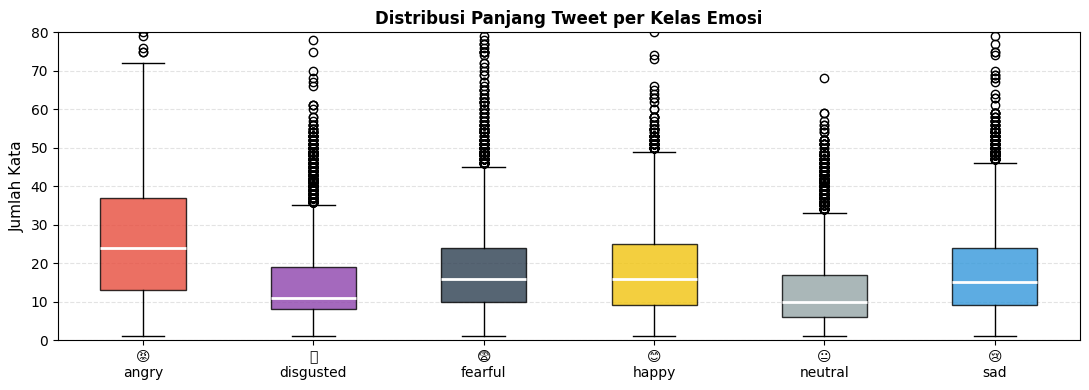

=== Persentase Noise per Kelas (%) ===
           has_mention  has_url  has_hashtag
label                                       
angry             64.5     10.2          9.3
disgusted         34.2      5.3          4.2
fearful           11.5      1.4         15.4
happy             55.9     20.1         24.7
neutral           34.8      4.2          1.4
sad               14.7      1.4          7.0


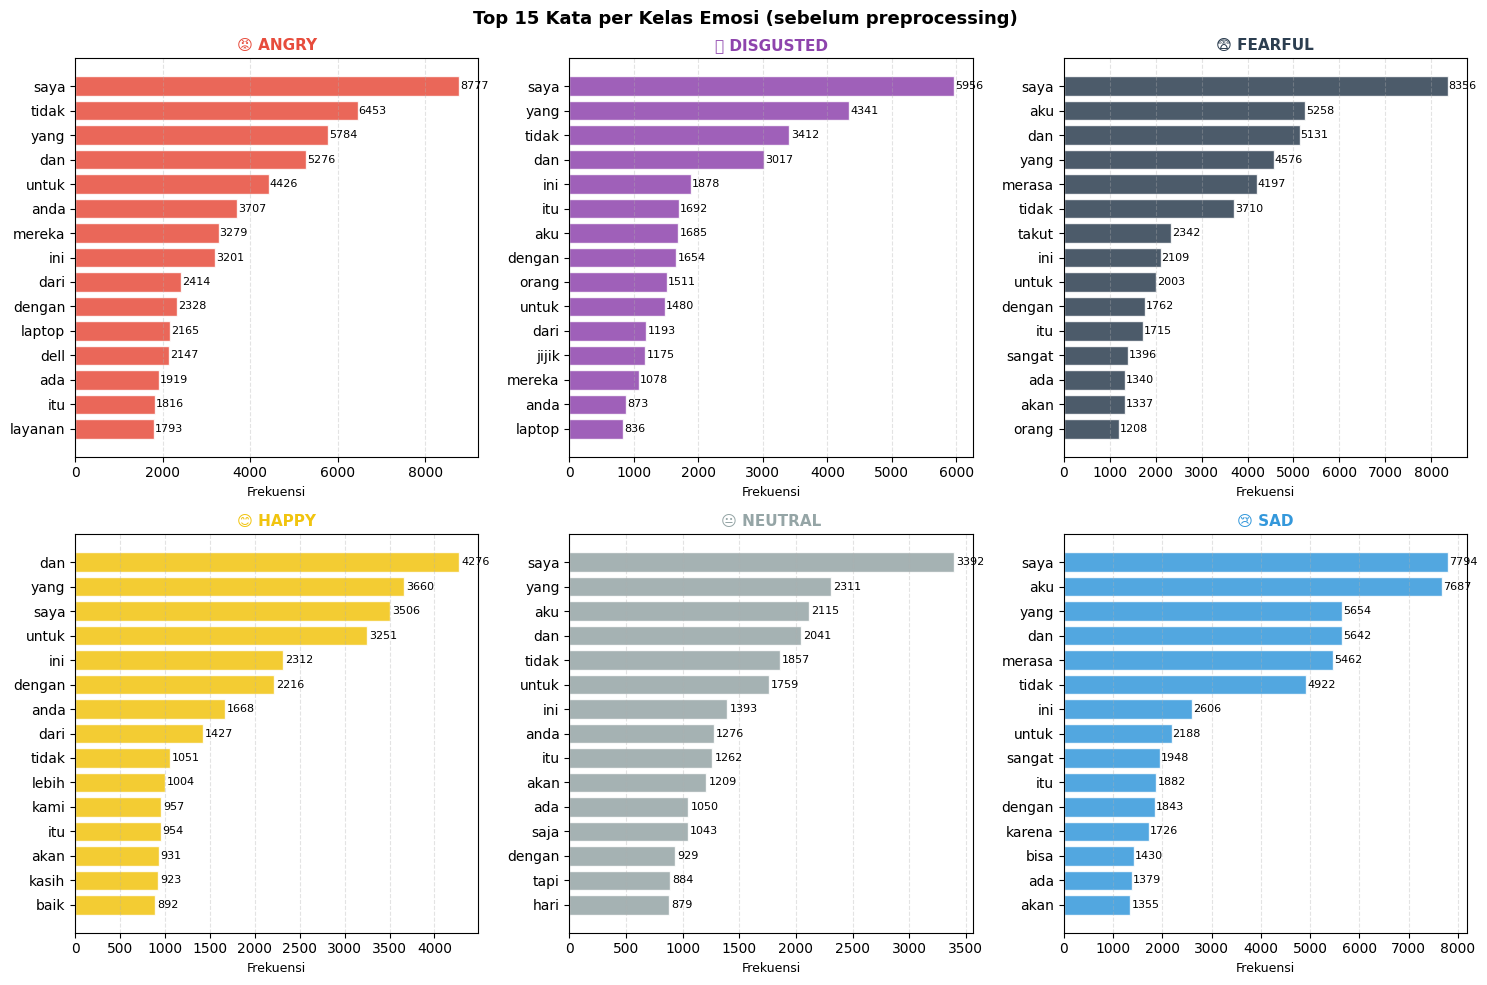


=== Ringkasan EDA ===
Total data           : 73,672
Jumlah kelas         : 6
Missing value        : 0
Rata-rata jumlah kata: 17.7
Kelas terpanjang     : angry
Kelas terpendek      : neutral


In [ ]:
# EXPLORATORY DATA ANALYSIS (EDA)
import warnings
warnings.filterwarnings("ignore")

emotion_colors = {
    'angry'    : '#E74C3C',
    'disgusted': '#8E44AD',
    'fearful'  : '#2C3E50',
    'happy'    : '#F1C40F',
    'neutral'  : '#95A5A6',
    'sad'      : '#3498DB'
}
labels_order = ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad']
emotion_emoji = {
    'angry':'😡', 'disgusted':'🤢', 'fearful':'😨',
    'happy':'😊', 'neutral':'😐', 'sad':'😢'
}
colors = [emotion_colors[l] for l in labels_order]

# 1. Distribusi Kelas
dist = df['label'].value_counts().reindex(labels_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribusi Kelas Emosi', fontsize=14, fontweight='bold')

bars = axes[0].bar(labels_order, dist.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_xlabel('Kelas Emosi', fontsize=11)
axes[0].set_ylabel('Jumlah Data', fontsize=11)
axes[0].set_title('Jumlah Data per Kelas', fontsize=11)
axes[0].grid(axis='y', alpha=0.35, linestyle='--')
for bar, val in zip(bars, dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].pie(dist.values, labels=labels_order, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Proporsi Tiap Kelas (%)', fontsize=11)

plt.tight_layout()
plt.show()

# 2. Panjang Teks per Kelas
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(11, 4))
data_word = [df[df['label'] == l]['word_count'].values for l in labels_order]
bp = ax.boxplot(data_word, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_xticklabels([f"{emotion_emoji[l]}\n{l}" for l in labels_order], fontsize=10)
ax.set_ylabel('Jumlah Kata', fontsize=11)
ax.set_title('Distribusi Panjang Tweet per Kelas Emosi', fontsize=12, fontweight='bold')
ax.set_ylim(0, 80)
ax.grid(axis='y', alpha=0.35, linestyle='--')
plt.tight_layout()
plt.show()

# 3. Deteksi Noise
df['has_mention'] = df['text'].str.contains(r'@\w+', regex=True)
df['has_url']     = df['text'].str.contains(r'http\S+', regex=True)
df['has_hashtag'] = df['text'].str.contains(r'#\w+', regex=True)

noise_pct = (df.groupby('label')[['has_mention','has_url','has_hashtag']]
               .mean() * 100).round(1)
print("=== Persentase Noise per Kelas (%) ===")
print(noise_pct.to_string())

# 4. Top 15 kata per kelas
def get_top_words(texts, n=15):
    all_words = []
    for t in texts:
        words = re.sub(r'http\S+|@\w+|#\w+', '', str(t).lower())
        words = re.sub(r'[^a-zA-Z\s]', ' ', words)
        all_words.extend([w for w in words.split() if len(w) > 2])
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Top 15 Kata per Kelas Emosi (sebelum preprocessing)',
             fontsize=13, fontweight='bold')

for ax, label in zip(axes.flatten(), labels_order):
    top = get_top_words(df[df['label'] == label]['text'])
    words  = [w for w, _ in top]
    counts = [c for _, c in top]
    color  = emotion_colors[label]
    bars = ax.barh(words[::-1], counts[::-1], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{emotion_emoji[label]} {label.upper()}', fontsize=11,
                 fontweight='bold', color=color)
    ax.set_xlabel('Frekuensi', fontsize=9)
    ax.grid(axis='x', alpha=0.35, linestyle='--')
    for bar, cnt in zip(bars, counts[::-1]):
        ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                str(cnt), va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\n=== Ringkasan EDA ===")
print(f"Total data           : {len(df):,}")
print(f"Jumlah kelas         : {df['label'].nunique()}")
print(f"Missing value        : {df[['label','text']].isnull().sum().sum()}")
print(f"Rata-rata jumlah kata: {df['word_count'].mean():.1f}")
print(f"Kelas terpanjang     : {df.groupby('label')['word_count'].mean().idxmax()}")
print(f"Kelas terpendek      : {df.groupby('label')['word_count'].mean().idxmin()}")

In [ ]:
# TEXT PREPROCESSING — PySastrawi

# Inisialisasi tools
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Stopwords Bahasa Indonesia: NLTK + kata gaul / singkatan umum
stop_words_id = set(stopwords.words('indonesian'))
extra_stops = {
    'yg', 'dgn', 'utk', 'krn', 'karna', 'nya', 'gue', 'gw',
    'aku', 'saya', 'kamu', 'dia', 'itu', 'ini', 'ada', 'aja', 'deh',
    'sih', 'lah', 'kah', 'dong', 'juga', 'udah', 'sudah', 'bisa',
    'mau', 'tapi', 'atau', 'dan', 'ke', 'di', 'dari', 'yang', 'untuk',
    'dengan', 'pada', 'http', 'https', 'rt', 'amp', 'via', 'ya',
    'ga', 'gak', 'nggak', 'tidak', 'bgt', 'banget'
}
stop_words_id.update(extra_stops)
print(f"Total stopword: {len(stop_words_id)}")

# Preprocessing
def preprocess_text(text):
    # 1. Lowercase
    text = str(text).lower()
    # 2. Hapus URL
    text = re.sub(r'http\S+|www\S+', ' ', text)
    # 3. Hapus mention (@username)
    text = re.sub(r'@\w+', ' ', text)
    # 4. Hapus hashtag (#topik)
    text = re.sub(r'#\w+', ' ', text)
    # 5. Hapus HTML entity (&amp; &lt; dll)
    text = re.sub(r'&\w+;', ' ', text)
    # 6. Hapus angka
    text = re.sub(r'\d+', ' ', text)
    # 7. Hapus tanda baca & karakter non-alfabet
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # 8. Normalisasi karakter berulang (hahaha → haha, kesel!!! → tetap kesel)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    # 9. Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    # 10. Tokenisasi & hapus stopword
    tokens = [t for t in text.split()
              if t not in stop_words_id and len(t) > 2]
    # 11. Stemming dengan PySastrawi
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

print("\n=== Tes Preprocessing (5 sampel) ===")
samples = [
    "kali mual sakit berita negeri anjrit pengen marah2 capek gak nyerah bangsat",
    "@sir_azri bekas polis rasuah dibuang kerja jijik! mual! najis!! https://t.co/abc123",
    "trypophobia fobia takut pola berlubang kumpulan lubang kecil penderita merinding",
    "Alhamdulillah akhirnya lulus sidang senang banget, makasih doa teman2 semua!",
    "Gempa tadi malam bikin aku gemetar takut banget rasanya, deg-degan terus",
]
for i, s in enumerate(samples):
    print(f"\nOriginal  [{i+1}]: {s[:80]}")
    print(f"Processed [{i+1}]: {preprocess_text(s)}")

tqdm.pandas()
df['text_clean'] = df['text'].progress_apply(preprocess_text)

# Hapus baris kosong setelah preprocessing
df_clean = df[df['text_clean'].str.strip() != ''].copy().reset_index(drop=True)

print(f"\n=== Hasil Preprocessing ===")
print(f"Data sebelum : {len(df):,}")
print(f"Data sesudah : {len(df_clean):,}")
print(f"Baris dihapus: {len(df) - len(df_clean)} (kosong setelah preprocessing)")

print("\n=== Contoh Sebelum vs Sesudah ===")
for _, row in df_clean.sample(3, random_state=42).iterrows():
    print(f"\n[{row['label'].upper()}]")
    print(f"  Before : {row['text'][:100]}")
    print(f"  After  : {row['text_clean'][:100]}")

Total stopword: 781

=== Tes Preprocessing (5 sampel) ===

Original  [1]: kali mual sakit berita negeri anjrit pengen marah2 capek gak nyerah bangsat
Processed [1]: kali mual sakit berita negeri anjrit ken marah capek nyerah bangsat

Original  [2]: @sir_azri bekas polis rasuah dibuang kerja jijik! mual! najis!! https://t.co/abc
Processed [2]: bekas polis rasuah buang kerja jijik mual najis

Original  [3]: trypophobia fobia takut pola berlubang kumpulan lubang kecil penderita merinding
Processed [3]: trypophobia fobia takut pola lubang kumpul lubang derita merinding

Original  [4]: Alhamdulillah akhirnya lulus sidang senang banget, makasih doa teman2 semua!
Processed [4]: alhamdulillah lulus sidang senang makasih doa teman

Original  [5]: Gempa tadi malam bikin aku gemetar takut banget rasanya, deg-degan terus
Processed [5]: gempa malam bikin gemetar takut deg degan


100%|██████████| 73672/73672 [00:12<00:00, 5817.97it/s]



=== Hasil Preprocessing ===
Data sebelum : 73,672
Data sesudah : 72,839
Baris dihapus: 833 (kosong setelah preprocessing)

=== Contoh Sebelum vs Sesudah ===

[HAPPY]
  Before : semangat buat hari ini ya!! u deserve to be happy. anw, jgn lupa sarapan adet
  After  : semangat deserve happy anw jgn lupa sarap adet

[HAPPY]
  Before : alhamdulillah pagi pagi dspet kabar baik sehat selalu yaa sayang kuu
  After  : alhamdulillah pagi pagi dspet kabar sehat yaa sayang kuu

[FEARFUL]
  Before : Saya merasa saya harus melepaskan indera peraba karena saya takut merasakan sakit atau penderitaan y
  After  : lepas indera aba takut rasa sakit derita aku salah sulit hidup


In [ ]:
# TOKENISASI & PADDING
# Hyperparameter
VOCAB_SIZE    = 10000  # Ukuran vocabulary
MAX_LEN       = 50     # Panjang maks sequence (tweet Indonesia rata-rata ~15-20 kata)
EMBEDDING_DIM = 64     # Dimensi embedding vector per kata
TEST_SIZE     = 0.20   # Proporsi data test
VAL_SIZE      = 0.10   # Proporsi data validasi

# Encode label → integer
le = LabelEncoder()
y = le.fit_transform(df_clean['label'])
X = df_clean['text_clean'].values

print(f"Mapping label: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"Kelas        : {le.classes_.tolist()}")
print(f"Jumlah kelas : {len(le.classes_)}")
NUM_CLASSES = len(le.classes_)

# Split data
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=42, stratify=y_temp)

print(f"\nJumlah data:")
print(f"  Train      : {len(X_train):,}")
print(f"  Validation : {len(X_val):,}")
print(f"  Test       : {len(X_test):,}")

# Tokenisasi — fit HANYA pada training data!
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Konversi teks → sequence integer
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Padding: samakan panjang semua sequence
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

# Contoh tokenisasi
idx = 0
print(f"\nContoh tokenisasi (data ke-{idx}):")
print(f"  Teks asli   : '{X_train[idx]}'")
print(f"  Sequence    : {X_train_seq[idx]}")
print(f"  Setelah pad : {X_train_pad[idx]}")
print(f"\nShape X_train_pad : {X_train_pad.shape}")
print(f"Vocabulary aktual  : {len(tokenizer.word_index):,} kata unik")

Mapping label: {'angry': np.int64(0), 'disgusted': np.int64(1), 'fearful': np.int64(2), 'happy': np.int64(3), 'neutral': np.int64(4), 'sad': np.int64(5)}
Kelas        : ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad']
Jumlah kelas : 6

Jumlah data:
  Train      : 50,987
  Validation : 7,284
  Test       : 14,568

Contoh tokenisasi (data ke-0):
  Teks asli   : 'memberitahu pikir langgan case poin temu halaman referensi biar langgan sila tunjuk'
  Sequence    : [421, 14, 27, 1424, 1476, 44, 437, 1773, 81, 27, 549, 664]
  Setelah pad : [ 421   14   27 1424 1476   44  437 1773   81   27  549  664    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]

Shape X_train_pad : (50987, 50)
Vocabulary aktual  : 32,902 kata unik


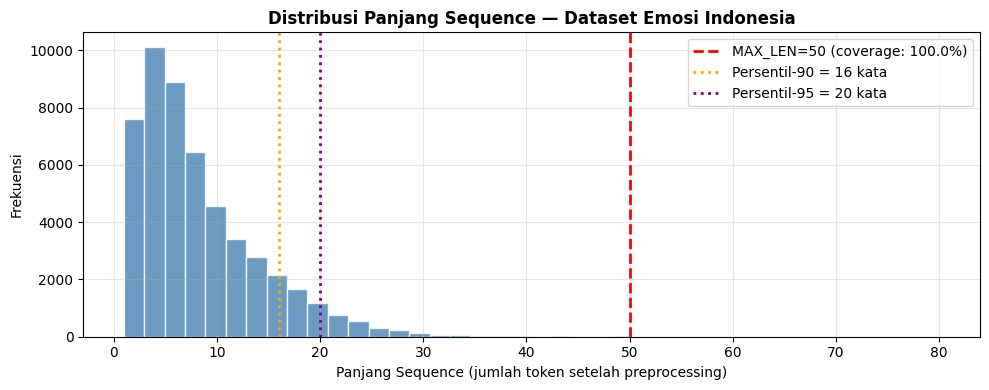

Dengan MAX_LEN=50:
  100.0% tweet tercakup sepenuhnya
  0.0% tweet dipotong (truncated)
  Rata-rata panjang: 7.9 token


In [ ]:
# Visualisasi distribusi panjang sequence & coverage MAX_LEN
seq_lens = [len(s) for s in X_train_seq]
coverage = sum(1 for l in seq_lens if l <= MAX_LEN) / len(seq_lens) * 100
p90 = int(np.percentile(seq_lens, 90))
p95 = int(np.percentile(seq_lens, 95))

plt.figure(figsize=(10, 4))
plt.hist(seq_lens, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
plt.axvline(MAX_LEN, color='red', lw=2, linestyle='--',
            label=f'MAX_LEN={MAX_LEN} (coverage: {coverage:.1f}%)')
plt.axvline(p90, color='orange', lw=2, linestyle=':',
            label=f'Persentil-90 = {p90} kata')
plt.axvline(p95, color='purple', lw=2, linestyle=':',
            label=f'Persentil-95 = {p95} kata')
plt.xlabel('Panjang Sequence (jumlah token setelah preprocessing)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Panjang Sequence — Dataset Emosi Indonesia', fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Dengan MAX_LEN={MAX_LEN}:")
print(f"  {coverage:.1f}% tweet tercakup sepenuhnya")
print(f"  {100-coverage:.1f}% tweet dipotong (truncated)")
print(f"  Rata-rata panjang: {np.mean(seq_lens):.1f} token")

<h3><font color="blue">Latihan 2:</font></h3>

<ul>
    <li>Mengapa kita hanya memanggil <code>tokenizer.fit_on_texts(X_train)</code> dan bukan <code>fit_on_texts(X)</code> pada seluruh data? Apa akibatnya jika kita fit pada seluruh data termasuk test set?</li>
    <li>Apa perbedaan <code>padding='pre'</code> vs <code>padding='post'</code>? Untuk RNN, mana yang lebih disarankan dan mengapa?</li>
    <li>Jika <code>MAX_LEN=40</code> hanya mencakup 85% tweet, apakah lebih baik dinaikkan? Apa trade-off-nya?</li>
</ul>


### Latihan 2

#### 1. Mengapa hanya `fit_on_texts(X_train)` dan akibat jika fit pada seluruh data (`X`)?
* **Alasan:** Untuk mencegah terjadinya **data leakage** (kebocoran data). Evaluasi model Machine Learning yang baik harus mensimulasikan kondisi dunia nyata, di mana *test set* adalah data yang benar-benar baru (*unseen data*).
* **Akibat jika fit pada seluruh data:** Jika tokenizer di-fit pada seluruh data (termasuk *test set*), tokenizer akan "menghafal" semua kosakata yang ada di *test set*. Akibatnya, kita tidak bisa menguji bagaimana model menangani kata-kata yang belum pernah dilihat sebelumnya (*Out-of-Vocabulary* / OOV). Hasil evaluasi model pada *test set* akan menjadi bias dan terkesan lebih bagus dari performa aslinya (terlalu optimis).

---

#### 2. Perbedaan `padding='pre'` vs `padding='post'` dan Rekomendasi untuk RNN
* **Perbedaan:**
  * `padding='pre'`: Menambahkan *padding* (biasanya nilai 0) di **awal** *sequence* (sebelum kata pertama).
  * `padding='post'`: Menambahkan *padding* di **akhir** *sequence* (setelah kata terakhir).
* **Rekomendasi untuk RNN:** Sangat disarankan menggunakan **`padding='pre'`**.
* **Alasan:** Arsitektur RNN memproses data secara sekuensial (langkah demi langkah) dan memperbarui *hidden state*-nya. Jika kita menggunakan `post` padding pada urutan yang pendek, RNN akan memproses kata-kata bermakna terlebih dahulu, kemudian memproses rentetan *padding* 0 di akhir. Rentetan nol ini dapat membuat RNN secara bertahap "melupakan" informasi penting yang sudah diproses sebelumnya karena *hidden state*-nya terus di-overwrite oleh input kosong, sehingga output akhir menjadi kurang akurat. Dengan `pre` padding, RNN menyerap *padding* terlebih dahulu, lalu ditutup dengan memproses kata-kata aktual yang penting tepat sebelum menghasilkan output akhir.

---

#### 3. Jika `MAX_LEN=40` hanya mencakup 85% tweet, apakah lebih baik dinaikkan dan apa trade-off-nya?
* Belum tentu lebih baik dinaikkan. Perlu mempertimbangkan *trade-off* (untung-rugi).
* **Trade-off Menaikkan `MAX_LEN`:**
  * **Kelebihan:** Mencegah hilangnya informasi (*truncation*) dari 15% tweet yang panjang.
  * **Kekurangan:** Jika dinaikkan (misal agar *coverage* mendekati 100%), matriks data akan membesar secara signifikan. Mayoritas tweet (yang biasanya pendek) akan dijejali dengan sangat banyak *padding*. Hal ini menyebabkan **komputasi (waktu training) jauh lebih lama**, **konsumsi memori lebih besar**, dan terlalu banyak *padding* kadang dapat menambah *noise* yang menyulitkan model untuk belajar. Seringkali, inti makna atau sentimen dari sebuah teks/tweet sudah bisa ditangkap pada puluhan kata pertama, sehingga memotong sebagian teks yang sangat panjang adalah jalan tengah terbaik untuk efisiensi komputasi.

---
## 6. Implementasi Model: SimpleRNN, LSTM, dan BiLSTM

<p>Kita akan membangun tiga model dengan arsitektur dasar yang sama, hanya berbeda pada <strong>tipe recurrent layer</strong>-nya. Karena dataset ini memiliki <strong>6 kelas emosi</strong> (multi-class), perhatikan perbedaan konfigurasi output dibandingkan klasifikasi biner:</p>

<table border="1" cellpadding="8" cellspacing="0">
<tr><th>Aspek</th><th>Klasifikasi Biner</th><th>Klasifikasi Multi-kelas (Emosi)</th></tr>
<tr><td><strong>Output layer</strong></td><td><code>Dense(1, activation='sigmoid')</code></td><td><code>Dense(6, activation='softmax')</code></td></tr>
<tr><td><strong>Loss function</strong></td><td><code>binary_crossentropy</code></td><td><code>sparse_categorical_crossentropy</code></td></tr>
<tr><td><strong>Output prediksi</strong></td><td>Probabilitas kelas positif (0–1)</td><td>Distribusi probabilitas 6 kelas (sum=1)</td></tr>
</table>

```
Embedding(VOCAB_SIZE, EMBEDDING_DIM)
       ↓
[SimpleRNN / LSTM / BiLSTM]  ← yang kita bandingkan
       ↓
Dropout(0.3)
       ↓
Dense(64, relu)
       ↓
Dense(6, softmax)  ← output: distribusi probabilitas 6 emosi
```

In [ ]:
# KONFIGURASI ARSITEKTUR
RNN_UNITS    = 64    # Jumlah unit pada recurrent layer
DROPOUT_RATE = 0.3   # Dropout rate
DENSE_UNITS  = 64    # Neuron dense layer
EPOCHS       = 10    # Epoch maksimum
BATCH_SIZE   = 128   # Batch size, jika pakai GPU bisa diperbesar
LR           = 0.0005 # Learning rate

# MODEL 1: SimpleRNN
def build_simple_rnn(vocab_size, emb_dim, max_len, units, dropout, num_classes):
    """SimpleRNN — RNN vanilla, baseline paling sederhana.
    Kelemahan utama: vanishing gradient untuk teks panjang.
    """
    model = Sequential([
        Embedding(vocab_size, emb_dim),
        SimpleRNN(units, dropout=dropout, name='simple_rnn'),
        Dropout(dropout, name='dropout'),
        Dense(DENSE_UNITS, activation='relu', name='dense'),
        # 6 kelas emosi → softmax
        Dense(num_classes, activation='softmax', name='output')
    ], name='SimpleRNN')
    return model

# MODEL 2: LSTM
def build_lstm(vocab_size, emb_dim, max_len, units, dropout, num_classes):
    """LSTM — Long Short-Term Memory.
    Mengatasi vanishing gradient dengan forget/input/output gates + cell state.
    """
    model = Sequential([
        Embedding(vocab_size, emb_dim),
        LSTM(units, dropout=dropout, name='lstm'),
        Dropout(dropout, name='dropout'),
        Dense(DENSE_UNITS, activation='relu', name='dense'),
        Dense(num_classes, activation='softmax', name='output')
    ], name='LSTM')
    return model

# MODEL 3: BiLSTM
def build_bilstm(vocab_size, emb_dim, max_len, units, dropout, num_classes):
    """BiLSTM — Bidirectional LSTM.
    Memproses teks dari kiri→kanan DAN kanan→kiri secara bersamaan.
    Setiap kata mendapat konteks penuh dari kedua sisi.
    merge_mode='concat' → output size = 2 × units
    """
    model = Sequential([
        Embedding(vocab_size, emb_dim),
        Bidirectional(
            LSTM(units, dropout=dropout, recurrent_dropout=0.1),
            merge_mode='concat',
            name='bilstm'
        ),
        Dropout(dropout, name='dropout'),
        Dense(DENSE_UNITS, activation='relu', name='dense'),
        Dense(num_classes, activation='softmax', name='output')
    ], name='BiLSTM')
    return model


# summary model sebagai contoh
for name, builder in [('SimpleRNN', build_simple_rnn),
                       ('LSTM',      build_lstm),
                       ('BiLSTM',    build_bilstm)]:

    m = builder(VOCAB_SIZE, EMBEDDING_DIM, MAX_LEN,
                RNN_UNITS, DROPOUT_RATE, NUM_CLASSES)
    m.build(input_shape=(None, MAX_LEN))
    m.compile('adam', 'sparse_categorical_crossentropy', metrics=['accuracy'])
    print(f"\n{'='*55}")
    print(f"Model: {name}  |  Total params: {m.count_params():,}")
    print(f"{'='*55}")

    m.summary()


Model: SimpleRNN  |  Total params: 652,806


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_45 (Embedding)        │ (None, 50, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,806 (2.49 MB)

 Trainable params: 652,806 (2.49 MB)

...

Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_47 (Embedding)        │ (None, 50, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 714,694 (2.73 MB)

 Trainable params: 714,694 (2.73 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# TRAINING & EVALUASI
import time

def train_and_evaluate(name, builder, X_tr, y_tr, X_v, y_v, X_te, y_te):
    """Melatih satu model dan mengembalikan hasil evaluasi."""
    print(f"\n{'─'*55}")
    print(f"  Training model: {name}")
    print(f"{'─'*55}")

    model = builder(VOCAB_SIZE, EMBEDDING_DIM, MAX_LEN,
                    RNN_UNITS, DROPOUT_RATE, NUM_CLASSES)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss='sparse_categorical_crossentropy',  # multi-kelas integer label
        metrics=['accuracy']
    )

    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=3,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, min_lr=1e-6, verbose=0)
    ]

    t_start = time.time()
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=callbacks, verbose=1
    )
    elapsed = time.time() - t_start

    test_loss, test_acc = model.evaluate(X_te, y_te, verbose=0)
    y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)

    print(f"\n Selesai | Acc: {test_acc*100:.2f}% | Waktu: {elapsed:.1f}s")
    return {
        'model':        model,
        'history':      history,
        'test_acc':     test_acc,
        'test_loss':    test_loss,
        'y_pred':       y_pred,
        'n_params':     model.count_params(),
        'elapsed':      elapsed,
        'best_val_acc': max(history.history['val_accuracy']),
    }

# TRAINING SEMUA MODEL
model_configs = [
    ('SimpleRNN', build_simple_rnn),
    ('LSTM',      build_lstm),
    ('BiLSTM',    build_bilstm),
]

results = {}
for name, builder in model_configs:
    results[name] = train_and_evaluate(
        name, builder,
        X_train_pad, y_train,
        X_val_pad,   y_val,
        X_test_pad,  y_test
    )


───────────────────────────────────────────────────────
  Training model: SimpleRNN
───────────────────────────────────────────────────────
Epoch 1/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3787 - loss: 1.5563 - val_accuracy: 0.5235 - val_loss: 1.3085 - learning_rate: 5.0000e-04
Epoch 2/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5646 - loss: 1.2268 - val_accuracy: 0.5612 - val_loss: 1.2334 - learning_rate: 5.0000e-04
Epoch 3/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6193 - loss: 1.0991 - val_accuracy: 0.5637 - val_loss: 1.2515 - learning_rate: 5.0000e-04
Epoch 4/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6448 - loss: 1.0385 - val_accuracy: 0.5799 - val_loss: 1.2171 - learning_rate: 5.0000e-04
Epoch 5/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6636 - loss: 0.9908 - val_accuracy: 0.5815 - val_loss: 1.2310 - learning_rate: 5.0000e-04
Epoch 6/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6814 - loss

---
## 7. Evaluasi & Perbandingan Model

In [ ]:
# PERBANDINGAN HASIL
rows = []
for name, res in results.items():
    rows.append({
        'Model':             name,
        'Test Accuracy (%)': f"{res['test_acc']*100:.2f}",
        'Best Val Acc (%)':  f"{res['best_val_acc']*100:.2f}",
        'Test Loss':         f"{res['test_loss']:.4f}",
        'Parameters':        f"{res['n_params']:,}",
        'Training Time (s)': f"{res['elapsed']:.1f}",
    })
df_comp = pd.DataFrame(rows).sort_values('Test Accuracy (%)', ascending=False)

print("=" * 72)
print("  PERBANDINGAN HASIL MODEL — 6 KELAS EMOSI")
print("=" * 72)
print(df_comp.to_string(index=False))
print("=" * 72)

  PERBANDINGAN HASIL MODEL — 6 KELAS EMOSI
    Model Test Accuracy (%) Best Val Acc (%) Test Loss Parameters Training Time (s)
   BiLSTM             66.90            66.19    0.9886    714,694            1272.5
     LSTM             60.46            59.10    1.1453    677,574              43.1
SimpleRNN             59.35            59.07    1.2399    652,806              40.1


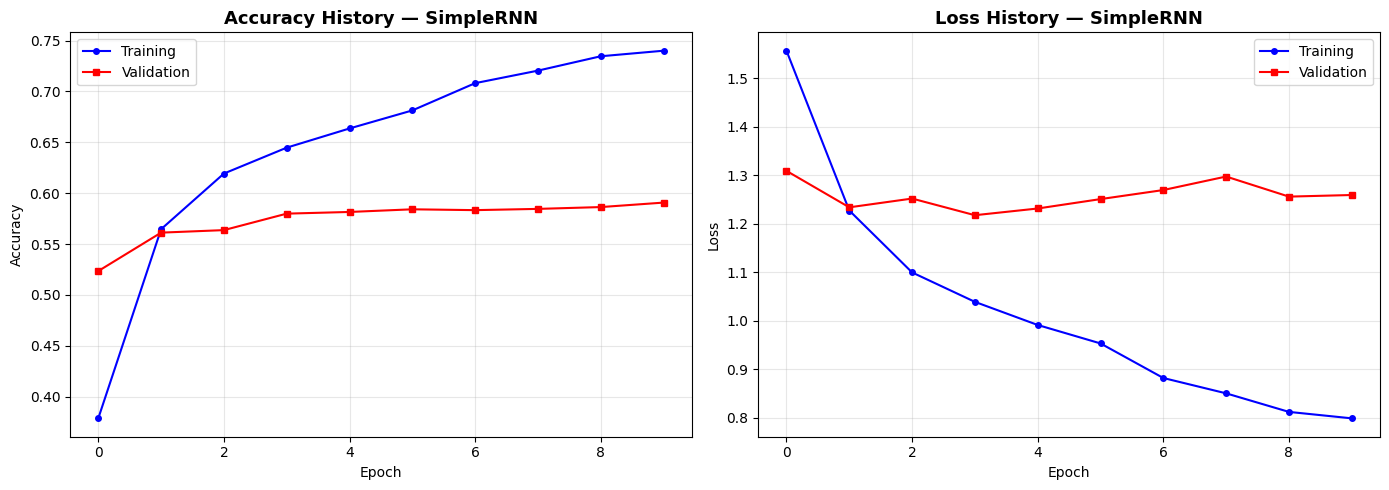

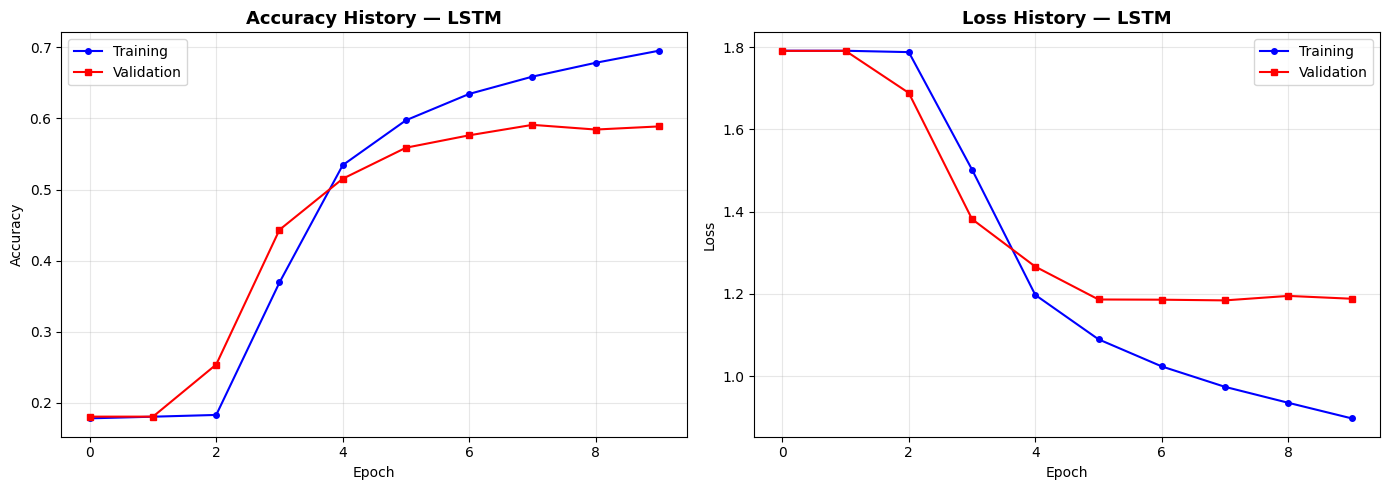

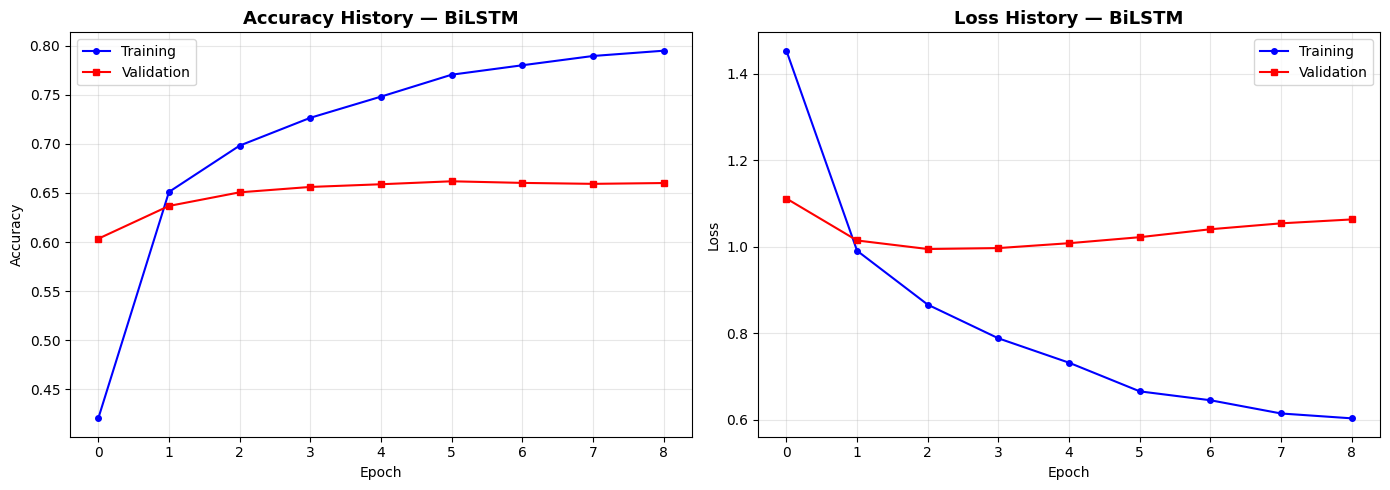

In [ ]:
# Fungsi plot training history
def plot_history(history, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'],     'b-o', ms=4, label='Training')
    ax1.plot(history.history['val_accuracy'], 'r-s', ms=4, label='Validation')
    ax1.set_title(f'Accuracy History {title}', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'],     'b-o', ms=4, label='Training')
    ax2.plot(history.history['val_loss'], 'r-s', ms=4, label='Validation')
    ax2.set_title(f'Loss History {title}', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot untuk setiap model
for name, res in results.items():
    plot_history(res['history'], f'— {name}')

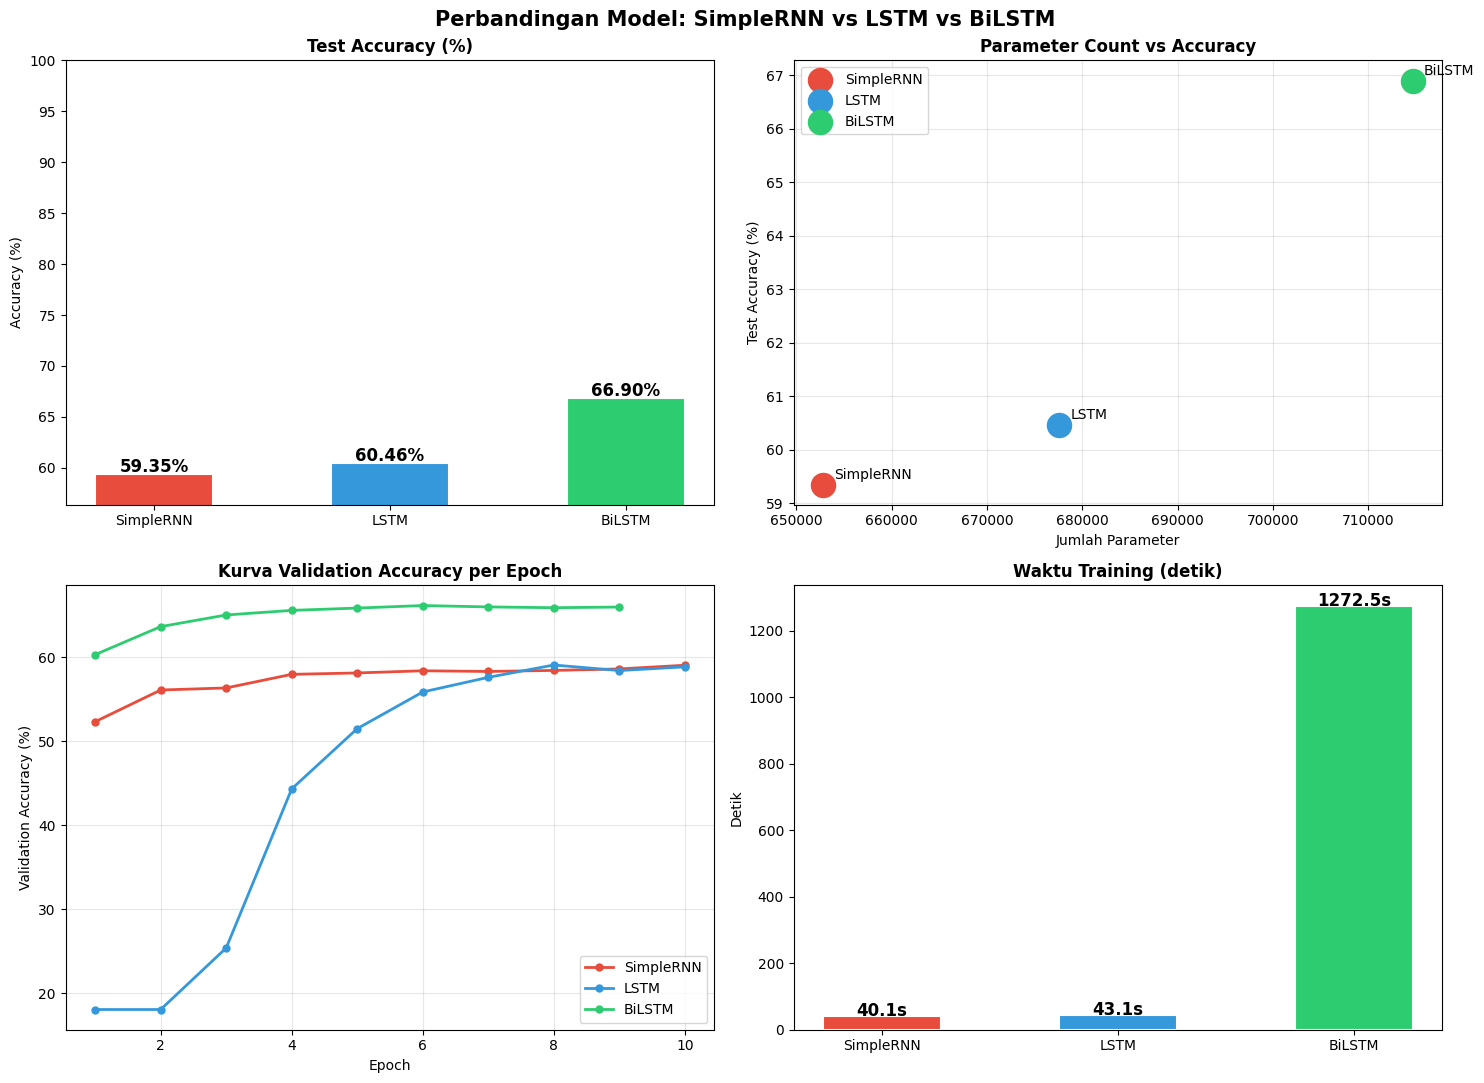

In [ ]:
# VISUALISASI
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Perbandingan Model: SimpleRNN vs LSTM vs BiLSTM',
             fontsize=15, fontweight='bold')

names  = list(results.keys())
colors = ['#e74c3c', '#3498db', '#2ecc71']
accs   = [results[n]['test_acc'] * 100 for n in names]

# 1. Bar chart Test Accuracy
bars = axes[0,0].bar(names, accs, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0,0].set_ylim(min(accs) * 0.95, 100)
axes[0,0].set_title('Test Accuracy (%)', fontweight='bold')
axes[0,0].set_ylabel('Accuracy (%)')
for bar, val in zip(bars, accs):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                   f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')

# 2. Parameter vs Accuracy scatter
params = [results[n]['n_params'] for n in names]
for n, a, p, c in zip(names, accs, params, colors):
    axes[0,1].scatter(p, a, s=300, color=c, zorder=5, label=n)
    axes[0,1].annotate(n, (p, a), textcoords='offset points',
                       xytext=(8, 4), fontsize=10)
axes[0,1].set_xlabel('Jumlah Parameter')
axes[0,1].set_ylabel('Test Accuracy (%)')
axes[0,1].set_title('Parameter Count vs Accuracy', fontweight='bold')
axes[0,1].legend(fontsize=10)
axes[0,1].grid(True, alpha=0.3)

# 3. Kurva val_accuracy per epoch
for n, c in zip(names, colors):
    val_acc = results[n]['history'].history['val_accuracy']
    axes[1,0].plot(range(1, len(val_acc)+1), [v*100 for v in val_acc],
                   marker='o', ms=5, color=c, label=n, linewidth=2)
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Validation Accuracy (%)')
axes[1,0].set_title('Kurva Validation Accuracy per Epoch', fontweight='bold')
axes[1,0].legend(fontsize=10); axes[1,0].grid(True, alpha=0.3)

# 4. Waktu training
times = [results[n]['elapsed'] for n in names]
bars2 = axes[1,1].bar(names, times, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[1,1].set_title('Waktu Training (detik)', fontweight='bold')
axes[1,1].set_ylabel('Detik')
for bar, val in zip(bars2, times):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   f'{val:.1f}s', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

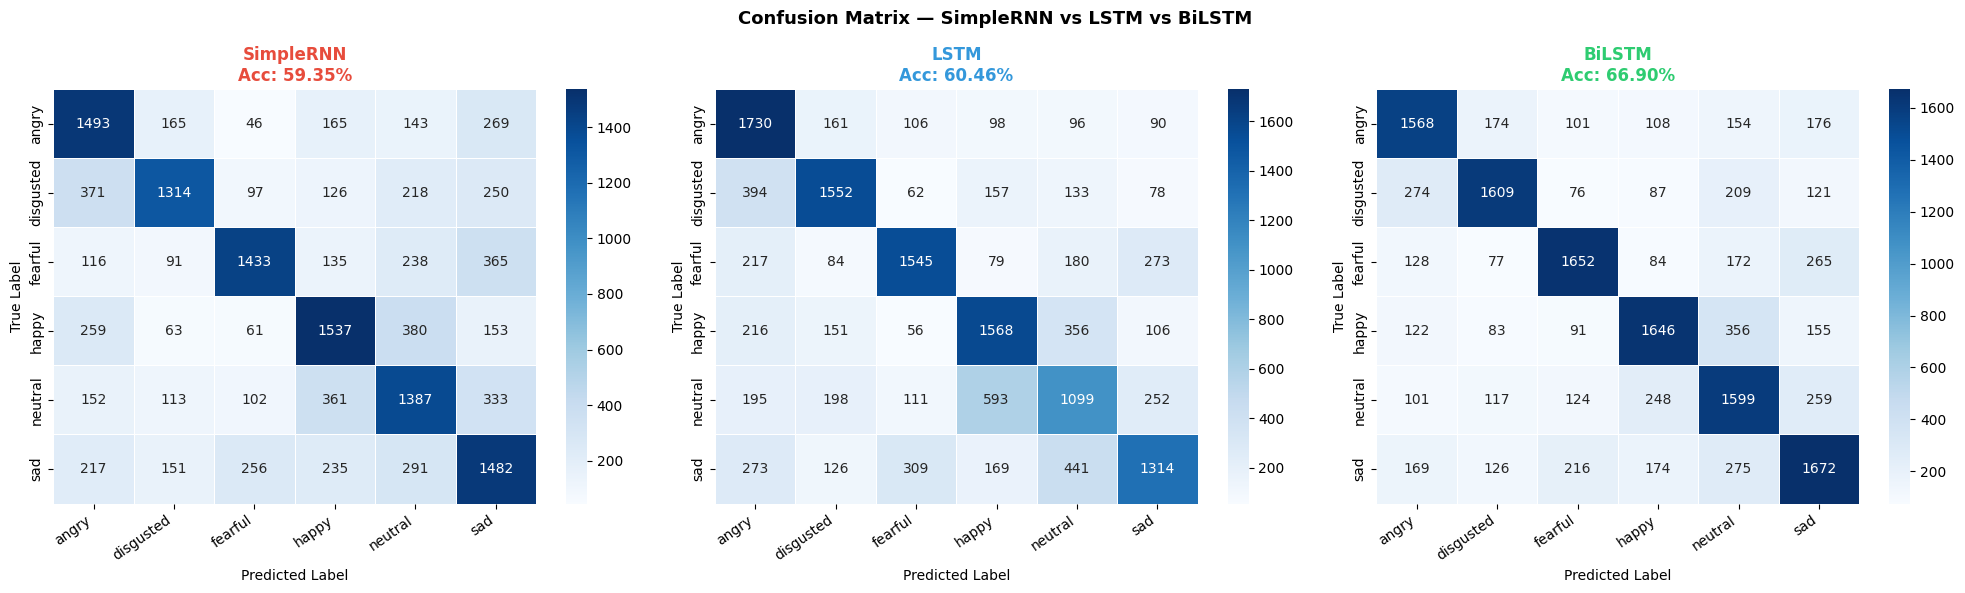


 Classification Report — BiLSTM (Model Terbaik) 
              precision    recall  f1-score   support

       angry       0.66      0.69      0.68      2281
   disgusted       0.74      0.68      0.71      2376
     fearful       0.73      0.69      0.71      2378
       happy       0.70      0.67      0.69      2453
     neutral       0.58      0.65      0.61      2448
         sad       0.63      0.64      0.63      2632

    accuracy                           0.67     14568
   macro avg       0.67      0.67      0.67     14568
weighted avg       0.67      0.67      0.67     14568



In [ ]:
# CONFUSION MATRIX & CLASSIFICATION REPORT
kelas_emosi  = le.classes_.tolist()
model_names  = list(results.keys())
colors_model = ['#e74c3c', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrix — SimpleRNN vs LSTM vs BiLSTM',
             fontsize=13, fontweight='bold')

for ax, (name, col) in zip(axes, zip(model_names, colors_model)):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=kelas_emosi, yticklabels=kelas_emosi,
                linewidths=0.5)
    acc = results[name]['test_acc']
    ax.set_title(f'{name}\nAcc: {acc*100:.2f}%', fontweight='bold', color=col)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.setp(ax.get_xticklabels(), rotation=35, ha='right')

plt.tight_layout()
plt.show()

# Classification report model terbaik
best_name = max(results, key=lambda n: results[n]['test_acc'])
print(f"\n Classification Report — {best_name} (Model Terbaik) ")
print("=" * 60)
print(classification_report(y_test, results[best_name]['y_pred'],
                             target_names=kelas_emosi))

<h3><font color="blue">Latihan 3:</font></h3>

<ul>
    <li>Perhatikan confusion matrix 6 kelas. Pasangan kelas mana yang paling sering <strong>tertukar</strong>? Apakah hasil ini masuk akal secara semantik? (misalnya: apakah <code>sad</code> sering tertukar dengan <code>neutral</code> atau <code>angry</code>?)</li>
    <li>Bandingkan jumlah parameter SimpleRNN vs LSTM vs BiLSTM. Mengapa BiLSTM memiliki ~2× parameter lebih banyak dari LSTM, padahal jumlah <code>units</code>-nya sama?</li>
    <li>Untuk dataset 6 kelas emosi yang lebih kompleks ini, apakah selisih performa antara ketiga model lebih besar atau lebih kecil dibandingkan yang Anda perkirakan? Jelaskan reasoning Anda.</li>
</ul>


### Latihan 3

#### 1. Pasangan Kelas yang Sering Tertukar pada Confusion Matrix
* **Observasi Grafik:** Jika kita melihat angka-angka di luar diagonal utama (kesalahan prediksi), pasangan yang sangat sering tertukar adalah **`neutral` dan `happy`** (contoh ekstrem di LSTM: 593 label `neutral` salah diprediksi sebagai `happy`). Pasangan lain yang juga sering tertukar secara signifikan adalah **`disgusted` dan `angry`** (contoh: 394 di LSTM), serta **`sad` dan `neutral`**.
* **Analisis Semantik:** Ya, hasil ini **sangat masuk akal secara semantik**:
  * **`neutral` vs `happy`:** Kalimat sehari-hari yang sopan atau sekadar basa-basi sering kali mengandung kata-kata bersentimen sedikit positif yang membingungkan model untuk membedakan antara netral atau bahagia.
  * **`disgusted` vs `angry`:** Keduanya adalah emosi negatif dengan tingkat energi/intensitas (*arousal*) yang tinggi. Kosakata yang digunakan sangat sering tumpang tindih (misalnya: umpatan, keluhan keras, kata-kata kasar).
  * **`sad` vs `neutral`:** Keduanya adalah emosi dengan intensitas rendah. Kalimat sedih yang implisit (tidak menggunakan kata "sedih/menangis") bisa terlihat sangat datar dan diklasifikasikan sebagai netral.

---

#### 2. Perbandingan Parameter: BiLSTM vs LSTM
* **Penjelasan:** Sesuai namanya (Bidirectional), BiLSTM pada dasarnya menginisialisasi dan menjalankan **dua layer LSTM yang benar-benar terpisah secara bersamaan**.
* Satu layer LSTM bertugas membaca urutan kata secara maju (*forward*, dari awal ke akhir teks), dan satu layer LSTM lainnya membaca secara mundur (*backward*, dari akhir ke awal teks).
* Karena model secara harfiah membangun dua arsitektur LSTM independen yang bekerja paralel, maka jumlah bobot/parameter yang harus dipelajari model secara otomatis akan menjadi sekitar **dua kali lipat** (2x) lebih banyak dibandingkan dengan LSTM biasa (satu arah) meskipun diatur dengan jumlah `units` yang sama.

---

#### 3. Selisih Performa Model (SimpleRNN vs LSTM vs BiLSTM)
* **Observasi Performa:** Akurasi yang didapat adalah SimpleRNN (59.35%), LSTM (60.46%), dan BiLSTM (66.90%).
* **Analisis Reasoning:** * **Selisih SimpleRNN ke LSTM tergolong lebih kecil dari perkiraan (~1.1%):** Pada dataset yang kompleks, LSTM biasanya jauh meninggalkan SimpleRNN. Namun, mengingat ini adalah dataset emosi Twitter/teks (merujuk Latihan 2 dimana rata-rata panjang *sequence* hanya sekitar 7.9 token), masalah memori jangka panjang (*vanishing gradient*) yang menjadi kelemahan utama SimpleRNN tidak terlalu terekspos. Karena kalimatnya pendek-pendek, SimpleRNN masih mampu bersaing.
  * **Selisih LSTM ke BiLSTM tergolong besar dan sesuai perkiraan (~6.4%):** Dalam klasifikasi teks 6 kelas yang ambigu, konteks kalimat sangat krusial. Seringkali kata di akhir kalimat memutarbalikkan emosi dari kata di awal (seperti sarkasme atau struktur kalimat inversi). Kemampuan BiLSTM untuk membaca dari dua arah memberikan pemahaman konteks semantik yang jauh lebih kaya, sehingga terbukti memberikan lonjakan akurasi yang paling signifikan.
"""

---
## 8. Eksperimen Konfigurasi Model

<p>Pada bagian ini kita akan melakukan eksperimen dengan berbagai konfigurasi untuk memahami pengaruh hyperparameter.</p>

Eksperimen A: Pengaruh Jumlah Unit pada LSTM
  units= 16 → Test Acc=16.31%  Params=645,201
  units= 32 → Test Acc=16.31%  Params=652,449
  units= 64 → Test Acc=16.31%  Params=673,089
  units=128 → Test Acc=16.31%  Params=738,945


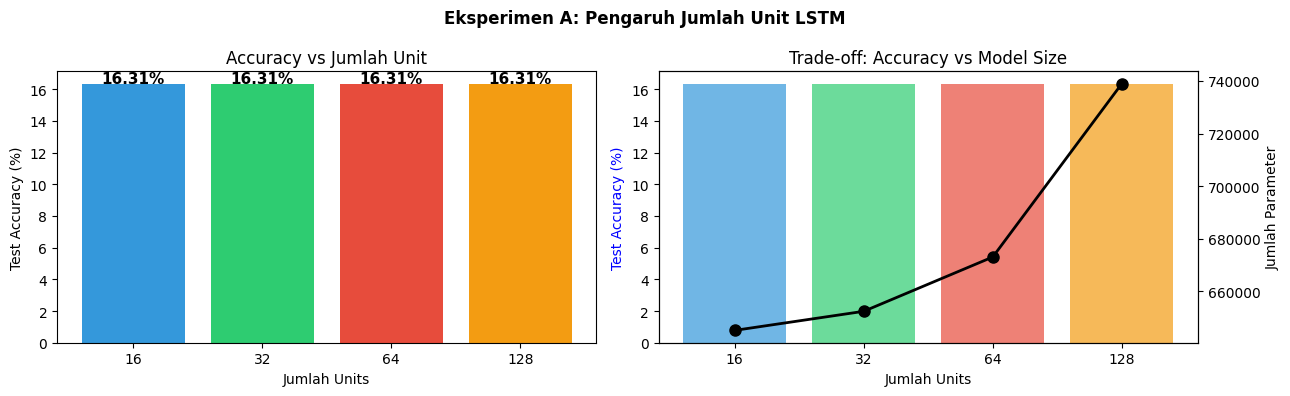

In [ ]:
# EKSPERIMEN Agus: Pengaruh Jumlah Unit LSTM
print("Eksperimen A: Pengaruh Jumlah Unit pada LSTM")

unit_list = [16, 32, 64, 128]
exp_a = []

for u in unit_list:
    m = Sequential([
        Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
        LSTM(u, dropout=0.2),
        Dense(1, activation='sigmoid')
    ])
    m.compile('adam', 'binary_crossentropy', metrics=['accuracy'])
    h = m.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val),
               epochs=5, batch_size=BATCH_SIZE, verbose=0)
    _, acc = m.evaluate(X_test_pad, y_test, verbose=0)
    exp_a.append({'units': u, 'acc': acc, 'params': m.count_params()})
    print(f"  units={u:3d} → Test Acc={acc*100:.2f}%  Params={m.count_params():,}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Eksperimen A: Pengaruh Jumlah Unit LSTM', fontweight='bold')

u_vals = [r['units'] for r in exp_a]
a_vals = [r['acc']*100 for r in exp_a]
p_vals = [r['params'] for r in exp_a]

bar_colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
axes[0].bar([str(u) for u in u_vals], a_vals, color=bar_colors)
for i, (u, a) in enumerate(zip(u_vals, a_vals)):
    axes[0].text(i, a + 0.1, f'{a:.2f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Jumlah Units')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Accuracy vs Jumlah Unit')

ax2b = axes[1].twinx()
axes[1].bar([str(u) for u in u_vals], a_vals, color=bar_colors, alpha=0.7, label='Accuracy')
ax2b.plot([str(u) for u in u_vals], p_vals, 'ko-', ms=8, linewidth=2, label='Params')
axes[1].set_xlabel('Jumlah Units')
axes[1].set_ylabel('Test Accuracy (%)', color='blue')
ax2b.set_ylabel('Jumlah Parameter', color='black')
axes[1].set_title('Trade-off: Accuracy vs Model Size')

plt.tight_layout()
plt.show()

Eksperimen B: Stacked LSTM — Pengaruh Kedalaman Model
  LSTM 1 Layer → Acc=16.31%  Params=673,089
  LSTM 2 Layer → Acc=16.31%  Params=685,473
  LSTM 3 Layer → Acc=16.32%  Params=688,593


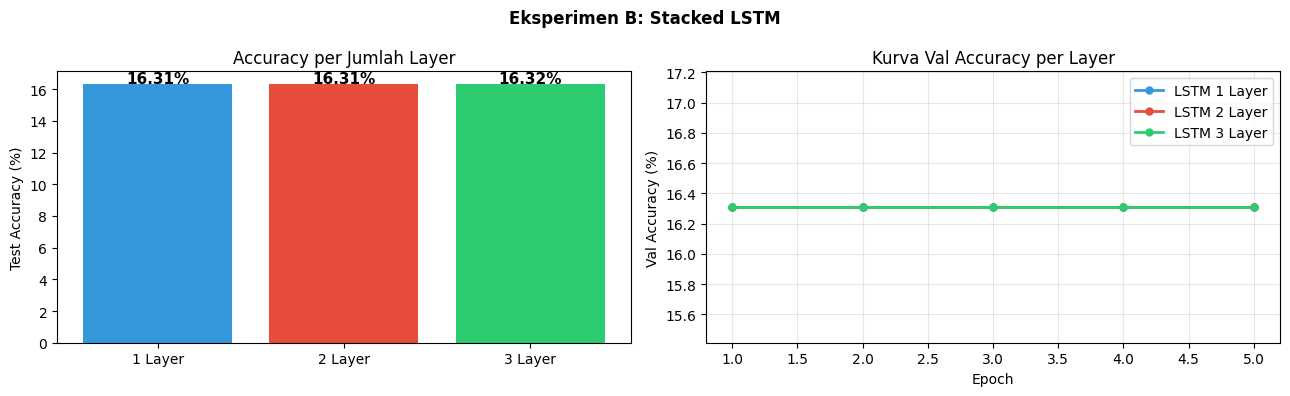


Catatan return_sequences:
  LSTM biasa   : output shape = (batch, units)
  return_seq=True : output shape = (batch, timestep, units)
  → Layer LSTM berikutnya butuh input 3D, jadi perlu return_sequences=True


In [ ]:
# EKSPERIMEN Budi: Stacked LSTM (Deep Sequence Model)
print("Eksperimen B: Stacked LSTM — Pengaruh Kedalaman Model")

# PENTING: Gunakan return_sequences=True jika ada LSTM layer di atasnya!

# LSTM 1 layer
lstm_1layer = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(64),                              # return_sequences=False (default)
    Dense(1, activation='sigmoid')
], name='LSTM_1Layer')

# LSTM 2 layer
lstm_2layer = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(64, return_sequences=True),       # ← WAJIB True jika ada LSTM berikutnya
    LSTM(32),                              # layer terakhir: return_sequences=False
    Dense(1, activation='sigmoid')
], name='LSTM_2Layer')

# LSTM 3 layer
lstm_3layer = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(64, return_sequences=True),
    LSTM(32, return_sequences=True),
    LSTM(16),
    Dense(1, activation='sigmoid')
], name='LSTM_3Layer')

exp_b = {}
for m_name, model in [('1 Layer', lstm_1layer),
                       ('2 Layer', lstm_2layer),
                       ('3 Layer', lstm_3layer)]:
    model.compile('adam', 'binary_crossentropy', metrics=['accuracy'])
    hist = model.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=5, batch_size=BATCH_SIZE, verbose=0,
        callbacks=[EarlyStopping(patience=2, restore_best_weights=True)]
    )
    _, acc = model.evaluate(X_test_pad, y_test, verbose=0)
    exp_b[m_name] = {'acc': acc, 'params': model.count_params(), 'hist': hist}
    print(f"  LSTM {m_name} → Acc={acc*100:.2f}%  Params={model.count_params():,}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Eksperimen B: Stacked LSTM', fontweight='bold')

b_names = list(exp_b.keys())
b_accs  = [exp_b[n]['acc']*100 for n in b_names]
b_cols  = ['#3498db', '#e74c3c', '#2ecc71']

axes[0].bar(b_names, b_accs, color=b_cols)
for i, a in enumerate(b_accs):
    axes[0].text(i, a + 0.1, f'{a:.2f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Accuracy per Jumlah Layer')

for n, c in zip(b_names, b_cols):
    va = [v*100 for v in exp_b[n]['hist'].history['val_accuracy']]
    axes[1].plot(range(1, len(va)+1), va, marker='o', ms=5, color=c, label=f'LSTM {n}', lw=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy (%)')
axes[1].set_title('Kurva Val Accuracy per Layer')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nCatatan return_sequences:")
print("  LSTM biasa   : output shape = (batch, units)")
print("  return_seq=True : output shape = (batch, timestep, units)")
print("  → Layer LSTM berikutnya butuh input 3D, jadi perlu return_sequences=True")

In [ ]:
# EKSPERIMEN Caca: BiLSTM dengan merge_mode yang berbeda
print("Eksperimen C: Pengaruh merge_mode pada BiLSTM")
# merge_mode menentukan bagaimana output forward & backward digabungkan

merge_modes = ['concat', 'sum', 'ave', 'mul']
exp_c = {}

for mode in merge_modes:
    m = Sequential([
        Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(32), merge_mode=mode),
        Dense(NUM_CLASSES, activation='softmax')   # sesuai dataset 6 kelas
    ])
    m.compile('adam', 'sparse_categorical_crossentropy', metrics=['accuracy'])
    m.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val),
          epochs=4, batch_size=BATCH_SIZE, verbose=0)
    _, acc = m.evaluate(X_test_pad, y_test, verbose=0)

    # Fix: gunakan m.output_shape bukan m.layers[1].output_shape ──
    out_shape = m.output_shape   # shape output layer terakhir model
    n_params  = m.count_params()

    exp_c[mode] = {'acc': acc, 'params': n_params, 'out_shape': out_shape}
    print(f"  merge_mode='{mode:6s}' → Acc={acc*100:.2f}%  Params={n_params:,}")

print("\nKeterangan output shape Bidirectional layer:")
print("  concat → units BiLSTM = 2×32 = 64  (fw concat bw)")
print("  sum    → units BiLSTM = 32          (fw + bw element-wise)")
print("  ave    → units BiLSTM = 32          (rata-rata fw dan bw)")
print("  mul    → units BiLSTM = 32          (perkalian fw dan bw)")

Eksperimen C: Pengaruh merge_mode pada BiLSTM
  merge_mode='concat' → Acc=66.17%  Params=665,222
  merge_mode='sum   ' → Acc=66.30%  Params=665,030
  merge_mode='ave   ' → Acc=66.43%  Params=665,030
  merge_mode='mul   ' → Acc=66.43%  Params=665,030

Keterangan output shape Bidirectional layer:
  concat → units BiLSTM = 2×32 = 64  (fw concat bw)
  sum    → units BiLSTM = 32          (fw + bw element-wise)
  ave    → units BiLSTM = 32          (rata-rata fw dan bw)
  mul    → units BiLSTM = 32          (perkalian fw dan bw)


<h3><font color="blue">Latihan 4:</font></h3>

<ul>
    <li>Dari Eksperimen A, apakah menambah units selalu meningkatkan accuracy? Pada titik berapa mulai menunjukkan diminishing returns atau overfitting?</li>
    <li>Dari Eksperimen B, jika LSTM 3-layer tidak lebih baik dari 1-layer, apa kemungkinan penyebabnya? Apa yang bisa dilakukan?</li>
    <li>Dari Eksperimen C, jelaskan perbedaan output shape antara <code>merge_mode='concat'</code> dan <code>merge_mode='sum'</code>. Kapan akan memilih <code>sum</code> dan kapan menggunakan <code>concat</code>?</li>
</ul>

### Latihan 4

#### 1. Eksperimen A: Pengaruh Jumlah Units
* **Apakah selalu meningkatkan accuracy?** Tidak. Menambah jumlah `units` memang meningkatkan kapasitas model untuk mempelajari pola kompleks, namun tren peningkatannya tidak akan berlangsung selamanya.
* **Titik Diminishing Returns & Overfitting:** Pada dataset teks standar, *diminishing returns* (penambahan parameter yang tidak sepadan dengan kenaikan akurasi) biasanya mulai terlihat saat melewati 64 atau 128 units. Jika units terus diperbesar (misal 256 ke atas), model akan mulai **overfitting**. Model menjadi terlalu kompleks dan akhirnya hanya "menghafal" data *training*, sehingga performa pada data *test* justru akan menurun drastis.

---

#### 2. Eksperimen B: Penyebab LSTM 3-Layer Kurang Optimal dan Solusinya
* **Kemungkinan Penyebab:**
  1. **Terlalu Kompleks (Over-parameterized):** Klasifikasi teks (terutama tweet/kalimat pendek) seringkali tidak membutuhkan abstraksi hierarkis sedalam itu. Model 3-layer memiliki terlalu banyak parameter untuk dataset yang relatif sederhana, sehingga sangat rawan terkena *overfitting*.
  2. **Masalah Propagasi (Vertikal):** Walaupun LSTM handal menangani data sekuensial yang panjang secara horizontal (waktu), menumpuk terlalu banyak *layer* secara vertikal (*stacked*) dapat mempersulit aliran *gradient* ke layer terbawah, membuat layer awal gagal belajar optimal.
* **Solusi yang bisa dilakukan:**
  * Cukup gunakan **1 atau maksimal 2 layer LSTM**. Untuk NLP tradisional, ini sering menjadi titik optimal (*sweet spot*).
  * Jika tetap ingin bereksperimen dengan model dalam (*deep*), pastikan untuk menambahkan **Dropout** dan **Recurrent Dropout** yang cukup besar (misal 0.3 - 0.5) untuk mencegah *overfitting*.

---

#### 3. Eksperimen C: Perbedaan Output Shape (`concat` vs `sum`)
* **Perbedaan Output Shape:**
  * `merge_mode='concat'`: Menggabungkan vektor dari proses *forward* dan *backward* secara bersebelahan panjangnya. Jika units LSTM adalah 32, maka output shape-nya menjadi dua kali lipat: **64** (karena 32 + 32).
  * `merge_mode='sum'`: Menjumlahkan nilai dari vektor *forward* dan *backward* secara *element-wise* (posisi per posisi). Jika units LSTM adalah 32, maka output shape-nya akan tetap **32**.
* **Kapan Memilih `concat`:** Ini adalah **pilihan default** dan paling direkomendasikan. Gunakan `concat` saat Anda ingin mempertahankan seluruh informasi dari dua arah secara utuh dan terpisah, membiarkan *layer* Dense berikutnya yang menentukan bobot dari masing-masing arah.
* **Kapan Memilih `sum`:** Gunakan `sum` jika Anda ingin **menghemat memori komputasi dan mengurangi jumlah parameter** pada *layer* berikutnya (seperti yang terlihat di parameter total eksperimen C, `sum` memiliki parameter lebih sedikit dari `concat`). Ini juga cocok jika Anda berasumsi kontribusi semantik kata dari kiri-ke-kanan dan kanan-ke-kiri bisa saling ditambahkan begitu saja tanpa perlu dipisah.

---
## 9. Prediksi pada Teks Baru

In [ ]:
# PREDIKSI PADA TEKS BARU
best_name  = max(results, key=lambda n: results[n]['test_acc'])
best_model = results[best_name]['model']
print(f"Model terbaik: {best_name} (Acc: {results[best_name]['test_acc']*100:.2f}%)\n")

def predict_emosi(teks_list, model, tokenizer, max_len, label_encoder):
    """Prediksi emosi untuk daftar teks baru."""
    clean  = [preprocess_text(t) for t in teks_list]
    seq    = tokenizer.texts_to_sequences(clean)
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    probs  = model.predict(padded, verbose=0)

    kelas = label_encoder.classes_
    emoji_map = {
        'angry':'😡', 'disgusted':'🤢', 'fearful':'😨',
        'happy':'😊', 'neutral':'😐', 'sad':'😢'
    }

    print(f"{'Teks Tweet':45s}  {'Emosi':12s}  Confidence")
    print("─" * 72)
    for teks, prob in zip(teks_list, probs):
        idx    = np.argmax(prob)
        label  = kelas[idx]
        conf   = prob[idx]
        emoji  = emoji_map[label]
        print(f"{teks[:44]:45s}  {emoji} {label:10s}  {conf*100:.1f}%")
    print("─" * 72)

# Test prediksi dengan kalimat Bahasa Indonesia
kalimat_baru = [
    "Alhamdulillah akhirnya lulus sidang, seneng banget!",
    "Anjing! Barang tidak datang padahal sudah bayar mahal!",
    "Jijik banget lihat kelakuan politisi korup itu",
    "Gempa tadi malam bikin aku gemetar takut banget rasanya",
    "Kangen banget sama almarhum ayah, sudah setahun kepergiannya",
    "Besok ada rapat jam 9 pagi di ruang meeting lantai 3",
    "Hujan deras dari tadi pagi, jalanan mulai banjir",
    "Dapet tiket konser favoritku, excited banget ga bisa tidur!",
]

predict_emosi(kalimat_baru, best_model, tokenizer, MAX_LEN, le)

Model terbaik: BiLSTM (Acc: 66.90%)

Teks Tweet                                     Emosi         Confidence
────────────────────────────────────────────────────────────────────────
Alhamdulillah akhirnya lulus sidang, seneng    😊 happy       96.6%
Anjing! Barang tidak datang padahal sudah ba   😡 angry       55.3%
Jijik banget lihat kelakuan politisi korup i   🤢 disgusted   99.8%
Gempa tadi malam bikin aku gemetar takut ban   😨 fearful     99.7%
Kangen banget sama almarhum ayah, sudah seta   😢 sad         94.9%
Besok ada rapat jam 9 pagi di ruang meeting    😐 neutral     91.1%
Hujan deras dari tadi pagi, jalanan mulai ba   😐 neutral     73.8%
Dapet tiket konser favoritku, excited banget   😊 happy       62.3%
────────────────────────────────────────────────────────────────────────


---
## 10. Prediksi Interaktif — Coba Kalimat Sendiri

<p>Gunakan cell di bawah untuk mencoba model pada kalimat Bahasa Indonesia bebas. Ketik kalimat yang mengandung emosi dan lihat prediksi model!</p>

In [ ]:
# ============================================================
# PREDIKSI INTERAKTIF — Widget dengan pilihan model
# ============================================================
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# ── Konfigurasi tampilan ─────────────────────────────────────
emotion_colors = {
    'angry'    : '#E74C3C',
    'disgusted': '#8E44AD',
    'fearful'  : '#2C3E50',
    'happy'    : '#F1C40F',
    'neutral'  : '#95A5A6',
    'sad'      : '#3498DB',
}
emotion_emoji = {
    'angry':'😡', 'disgusted':'🤢', 'fearful':'😨',
    'happy':'😊', 'neutral':'😐', 'sad':'😢',
}
emotion_desc = {
    'angry'    : 'Marah, kesal, tidak puas',
    'disgusted': 'Jijik, muak, tidak suka',
    'fearful'  : 'Takut, cemas, khawatir',
    'happy'    : 'Senang, bahagia, antusias',
    'neutral'  : 'Netral, informatif',
    'sad'      : 'Sedih, kecewa, berduka',
}
CHART_FONT = 'DejaVu Sans'

# ── Daftar model yang tersedia ────────────────────────────────
available_models = {name: res['model'] for name, res in results.items()}
model_acc = {name: res['test_acc'] for name, res in results.items()}

def predict_with_model(text_clean, model_name):
    """Prediksi menggunakan model yang dipilih, return (label, prob_array)."""
    model = available_models[model_name]
    seq   = tokenizer.texts_to_sequences([text_clean])
    pad   = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs = model.predict(pad, verbose=0)[0]
    label = le.classes_[np.argmax(probs)]
    return label, probs

# ── UI Components ─────────────────────────────────────────────
title_html = widgets.HTML(value="""
<div style="background:linear-gradient(135deg,#667eea 0%,#764ba2 100%);
            padding:18px 24px; border-radius:12px; margin-bottom:10px;">
    <h2 style="color:white; margin:0; font-size:18px;">
        Indonesian Emotion Classifier
    </h2>
    <p style="color:rgba(255,255,255,0.85); margin:5px 0 0; font-size:12px;">
        Klasifikasi 6 emosi: angry · disgusted · fearful · happy · neutral · sad
    </p>
</div>""")

# Buat label model + accuracy untuk toggle buttons
model_labels = [f"{name} ({model_acc[name]*100:.1f}%)" for name in available_models]
model_names  = list(available_models.keys())

model_selector = widgets.ToggleButtons(
    options      = model_labels,
    description  = 'Model:',
    button_style = '',
    layout       = widgets.Layout(width='100%')
)

text_input = widgets.Textarea(
    value       = '',
    placeholder = 'Ketik kalimat Bahasa Indonesia di sini... (minimal 2 kata)',
    layout      = widgets.Layout(width='100%', height='80px')
)

predict_btn = widgets.Button(
    description  = 'Prediksi',
    button_style = 'primary',
    layout       = widgets.Layout(width='120px', height='34px'),
)
clear_btn = widgets.Button(
    description  = 'Hapus',
    button_style = 'warning',
    layout       = widgets.Layout(width='90px', height='34px'),
)
char_counter = widgets.HTML(
    value='<span style="color:#aaa;font-size:12px;">0 karakter</span>'
)
output_area  = widgets.Output()
history_out  = widgets.Output()
history_list = []

# ── Event handlers ────────────────────────────────────────────
def on_text_change(change):
    n = len(change['new'])
    color = '#e74c3c' if n > 500 else '#aaa'
    char_counter.value = (
        f'<span style="color:{color};font-size:12px;">{n} karakter</span>'
    )
text_input.observe(on_text_change, names='value')

def on_predict_clicked(b):
    text = text_input.value.strip()
    with output_area:
        clear_output(wait=True)
        if not text or len(text.split()) < 2:
            display(HTML(
                '<div style="background:#fff3cd;border-left:4px solid #ffc107;'
                'padding:10px;border-radius:4px;color:#856404;font-size:13px;">'
                'Masukkan minimal 2 kata.</div>'
            ))
            return

        # Tentukan model yang dipilih
        sel_idx    = model_labels.index(model_selector.value)
        model_name = model_names[sel_idx]

        # Preprocessing & prediksi
        text_clean         = preprocess_text(text)
        emotion, probs     = predict_with_model(text_clean, model_name)
        top_conf           = float(probs[list(le.classes_).index(emotion)])
        conf_dict          = dict(zip(le.classes_, probs.tolist()))
        main_color         = emotion_colors[emotion]

        # Warna confidence
        conf_color = '#27ae60' if top_conf >= 0.4 else ('#f39c12' if top_conf >= 0.25 else '#e74c3c')
        conf_label = 'Tinggi' if top_conf >= 0.4 else ('Sedang' if top_conf >= 0.25 else 'Rendah')

        # ── Kartu hasil ──────────────────────────────────────
        display(HTML(f"""
        <div style="border:2px solid {main_color};border-radius:12px;
                    padding:16px 20px;margin:8px 0;background:#fafafa;">
            <div style="display:flex;align-items:center;gap:14px;">
                <div style="font-size:48px;line-height:1;">{emotion_emoji[emotion]}</div>
                <div style="flex:1;">
                    <div style="font-size:21px;font-weight:bold;color:{main_color};">
                        {emotion.upper()}
                        <span style="font-size:11px;color:#888;font-weight:normal;
                                     margin-left:8px;">via {model_name}</span>
                    </div>
                    <div style="font-size:12px;color:#555;margin-top:3px;">
                        {emotion_desc[emotion]}
                    </div>
                    <div style="margin-top:8px;">
                        <span style="background:{conf_color};color:white;
                                     padding:3px 11px;border-radius:20px;
                                     font-size:12px;font-weight:bold;">
                            Confidence {conf_label}: {top_conf:.1%}
                        </span>
                    </div>
                </div>
            </div>
        </div>"""))

        # ── Bar chart confidence per kelas ───────────────────
        fig, ax = plt.subplots(figsize=(6, 2.8))
        fig.patch.set_facecolor('white')
        cls_sorted  = sorted(conf_dict, key=conf_dict.get, reverse=True)
        vals_sorted = [conf_dict[c] for c in cls_sorted]
        clrs_sorted = [emotion_colors[c] for c in cls_sorted]
        bars = ax.barh(
            [f"{emotion_emoji[c]}  {c}" for c in cls_sorted],
            vals_sorted, color=clrs_sorted,
            edgecolor=['#333' if c == emotion else 'none' for c in cls_sorted],
            linewidth=[2 if c == emotion else 0 for c in cls_sorted],
            height=0.55
        )
        for bar, cls in zip(bars, cls_sorted):
            bar.set_alpha(1.0 if cls == emotion else 0.45)
        for bar, val in zip(bars, vals_sorted):
            ax.text(bar.get_width() + 0.006,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.1%}', va='center', fontsize=9.5,
                    color='#333', fontweight='bold')
        ax.set_xlim(0, max(vals_sorted) * 1.4)
        ax.set_title(f'Distribusi confidence per kelas — {model_name}',
                     fontsize=10, fontweight='bold')
        ax.tick_params(axis='y', labelsize=10)
        ax.grid(axis='x', alpha=0.25, linestyle='--')
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.tick_params(left=False)
        plt.tight_layout()
        plt.savefig('/tmp/conf_pred.png', dpi=130,
                    bbox_inches='tight', facecolor='white')
        plt.close()
        display(widgets.Image(
            value=open('/tmp/conf_pred.png', 'rb').read(),
            format='png',
            layout=widgets.Layout(width='500px')
        ))

        # Simpan riwayat
        history_list.insert(0, {
            'emoji': emotion_emoji[emotion],
            'teks' : text[:52] + ('...' if len(text) > 52 else ''),
            'emosi': emotion,
            'conf' : f'{top_conf:.1%}',
            'warna': main_color,
            'model': model_name,
        })
        update_history()

def update_history():
    with history_out:
        clear_output(wait=True)
        if not history_list:
            return
        rows = ''.join([
            f'<tr style="background:{"#f8f9fa" if i%2==0 else "white"};">'
            f'<td style="padding:6px 10px;font-size:12px;color:#bbb;text-align:center;">{i+1}</td>'
            f'<td style="padding:6px 12px;font-size:12px;color:#444;">{r["teks"]}</td>'
            f'<td style="padding:6px 10px;text-align:center;">'
            f'<span style="background:{r["warna"]}18;color:{r["warna"]};'
            f'border:1px solid {r["warna"]}55;padding:2px 10px;border-radius:20px;'
            f'font-size:11px;font-weight:bold;">{r["emoji"]} {r["emosi"]}</span></td>'
            f'<td style="padding:6px 8px;font-size:11px;color:#888;text-align:center;">{r["model"]}</td>'
            f'<td style="padding:6px 10px;font-size:12px;font-weight:bold;text-align:center;">{r["conf"]}</td>'
            f'</tr>'
            for i, r in enumerate(history_list[:8])
        ])
        display(HTML(f"""
        <div style="margin-top:14px;border-radius:10px;overflow:hidden;
                    border:1px solid #e8e8e8;">
            <div style="background:linear-gradient(135deg,#667eea,#764ba2);
                        padding:8px 16px;color:white;font-size:13px;font-weight:bold;">
                Riwayat Prediksi
                <span style="font-weight:normal;font-size:11px;opacity:.8;">
                    ({len(history_list)} entri)
                </span>
            </div>
            <table style="width:100%;border-collapse:collapse;
                           font-family:sans-serif;background:white;">
                <tr style="background:#f5f5fb;border-bottom:1px solid #eee;">
                    <th style="padding:6px 10px;font-size:11px;color:#aaa;width:28px;">#</th>
                    <th style="padding:6px 12px;font-size:11px;color:#aaa;text-align:left;">Teks</th>
                    <th style="padding:6px 10px;font-size:11px;color:#aaa;">Prediksi</th>
                    <th style="padding:6px 8px;font-size:11px;color:#aaa;">Model</th>
                    <th style="padding:6px 10px;font-size:11px;color:#aaa;">Conf.</th>
                </tr>
                {rows}
            </table>
        </div>"""))

def on_clear_clicked(b):
    text_input.value = ''
    with output_area:
        clear_output()

predict_btn.on_click(on_predict_clicked)
clear_btn.on_click(on_clear_clicked)

# ── Tombol contoh kalimat ─────────────────────────────────────
example_texts = {
    'Angry'    : 'Anjing bener! Sudah bayar mahal tapi barang tidak datang-datang!',
    'Disgusted': 'Jijik banget lihat tingkah politisi korup itu, mual rasanya',
    'Fearful'  : 'Gemetar banget, tadi ada gempa dan aku sendirian di rumah',
    'Happy'    : 'Alhamdulillah akhirnya lulus sidang, senang banget rasanya!',
    'Neutral'  : 'Besok ada rapat koordinasi jam 9 pagi di ruang meeting lantai 3',
    'Sad'      : 'Kangen banget sama almarhum ayah, sudah setahun lebih kepergiannya',
}
ex_btns = []
for lbl, txt in example_texts.items():
    color = emotion_colors[lbl.lower()]
    btn = widgets.Button(
        description = f'{emotion_emoji[lbl.lower()]} {lbl}',
        layout      = widgets.Layout(width='132px', height='30px'),
        style       = {'font_size': '12px', 'button_color': color + '22'},
    )
    def make_handler(t):
        def handler(b): text_input.value = t
        return handler
    btn.on_click(make_handler(txt))
    ex_btns.append(btn)

# ── Layout ────────────────────────────────────────────────────
display(widgets.VBox([
    title_html,
    widgets.HTML('<div style="font-size:12px;color:#888;margin:4px 0 3px;">Pilih model:</div>'),
    model_selector,
    text_input,
    widgets.HBox(
        [predict_btn, clear_btn, char_counter],
        layout=widgets.Layout(gap='8px', align_items='center', margin='6px 0')
    ),
    widgets.HTML('<div style="font-size:12px;color:#999;margin:6px 0 4px;">Coba contoh kalimat:</div>'),
    widgets.HBox(ex_btns[:3], layout=widgets.Layout(gap='6px')),
    widgets.HBox(ex_btns[3:], layout=widgets.Layout(gap='6px')),
    output_area,
    history_out,
], layout=widgets.Layout(width='700px')))


---
## Rangkuman

<table border="1" cellpadding="8" cellspacing="0">
<tr><th>Topik</th><th>Poin Penting</th></tr>
<tr>
    <td><strong>SimpleRNN</strong></td>
    <td>RNN vanilla; mudah diimplementasikan tapi rentan vanishing gradient untuk teks panjang; cocok sebagai baseline</td>
</tr>
<tr>
    <td><strong>LSTM</strong></td>
    <td>Menggunakan forget/input/output gate + cell state; mengatasi vanishing gradient; mampu belajar long-term dependency</td>
</tr>
<tr>
    <td><strong>BiLSTM</strong></td>
    <td>Memproses teks dari dua arah (forward + backward); setiap kata mendapat konteks penuh; ~2× parameter LSTM; sangat cocok untuk klasifikasi teks</td>
</tr>
<tr>
    <td><strong>Dataset</strong></td>
    <td>talithaolga/Indonesian-Emotion-Classification — 73.672 tweet Bahasa Indonesia, 6 kelas emosi, distribusi seimbang</td>
</tr>
<tr>
    <td><strong>Preprocessing</strong></td>
    <td>Lowercase → hapus URL/mention → hapus HTML entity → hapus angka/tanda baca → normalisasi karakter berulang → stopwords ID → stemming PySastrawi</td>
</tr>
<tr>
    <td><strong>Multi-class setup</strong></td>
    <td>Output: <code>Dense(6, softmax)</code>; Loss: <code>sparse_categorical_crossentropy</code>; Prediksi: <code>np.argmax()</code></td>
</tr>
<tr>
    <td><strong>Stacked RNN</strong></td>
    <td>Gunakan <code>return_sequences=True</code> pada semua recurrent layer kecuali yang terakhir</td>
</tr>
</table>

---

## Tugas Mini Project

### Tugas 1: Klasifikasi Emosi — Perbandingan dengan Paper

<ol type="a">
    <li>Lakukan klasifikasi emosi dari dataset <a href="https://github.com/meisaputri21/Indonesian-Twitter-Emotion-Dataset">Indonesian Twitter Emotion Dataset (GitHub)</a> menggunakan model <strong>RNN, LSTM, dan BiLSTM</strong>. Perhatikan dataset ini berbeda dari yang digunakan di hands-on (5 kelas: love, anger, sadness, joy, fear — bukan 6 kelas). Catat accuracy, precision, recall, dan F1-score tiap model.</li>
    <li>Bandingkan hasil Anda dengan paper: <a href="https://ieeexplore.ieee.org/document/8629262/">Emotion Classification on Indonesian Twitter Dataset (IEEE 2018)</a>. Apakah model deep learning Anda mencapai performa yang sama atau lebih baik dibanding model di paper?</li>
    <li>Lakukan <strong>scraping data</strong> dari X (Twitter) atau Threads sejumlah <strong>5.000 tweet</strong> berdasarkan keyword yang berkaitan dengan 5 kelas emosi (<em>love, anger, sadness, joy, fear</em>). Simpan dalam format CSV.</li>
    <li>Lakukan <strong>pseudo-labeling</strong> pada 5.000 data hasil scraping menggunakan model terbaik Anda sebagai <em>teacher model</em>. Referensi: <a href="https://www.analyticsvidhya.com/blog/2017/09/pseudo-labelling-semi-supervised-learning-technique/">Pseudo-labeling — Semi-Supervised Learning</a>. Latih ulang model dengan gabungan data original + data pseudo-labeled dan amati perubahannya.</li>
</ol>

### Tugas 2: Sequence Classification dengan Dataset Non-Teks

<p>Cari dataset sequential <strong>selain teks</strong> dari Kaggle, UCI, atau paper ilmiah. Lakukan klasifikasi/regresi menggunakan <strong>SimpleRNN, LSTM, dan BiLSTM</strong>. Bandingkan hasil ketiga model dan analisis model mana yang paling efisien.</p>

<p>Contoh dataset non-teks yang bisa digunakan:</p>
<ul>
    <li><strong>HAR (Human Activity Recognition)</strong> — klasifikasi aktivitas dari sensor accelerometer/gyroscope</li>
    <li><strong>ECG Classification</strong> — deteksi arrhythmia dari sinyal jantung</li>
    <li><strong>Air Quality Forecasting</strong> — prediksi kadar polutan dari time series sensor</li>
    <li><strong>EEG Motor Imagery</strong> — klasifikasi sinyal otak dari BCI dataset</li>
</ul>

---
<center><strong>Selamat Mengerjakan!</strong></center>